## Spatial analysis part b: isualize neuron subset distance to edge of DRG

There is evidence that neuron subsets of the same type localize with each other more than with other subsets (Krauter... Enfors et al., 202) https://www.nature.com/articles/s42003-025-08315-1#Sec2

We see this in our data as well. Are the differences in co-localization of neuron subsets related to the preference of subsets to localize to the DRG cente vs edge? To test this, we will calculate the distance of each cell to the closest DRG edge and summarize by cell subset.



In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2026-02-23 08:31:38.406242


In [2]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [3]:
import squidpy as sq

In [6]:
# make text editable as words in output plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [85]:
import matplotlib.colors as clr
import colorcet

zissou = [
    "#3A9AB2",
    "#6FB2C1",
    "#91BAB6",
    "#A5C2A3",
    "#BDC881",
    "#DCCB4E",
    "#E3B710",
    "#E79805",
    "#EC7A05",
    "#EF5703",
    "#F11B00",
]

colormap = clr.LinearSegmentedColormap.from_list("Zissou", zissou)
colormap_r = clr.LinearSegmentedColormap.from_list("Zissou", zissou[::-1])

In [171]:
base_dir = "/home/workspace/DRG"

# neurons
input_file = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/20260115_drg-gpu-backup/data/h5ad/export_04/04c_gamma_subtypes/neurons-final-labels.h5ad"
# global 
input_file_global = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/20260115_drg-gpu-backup/data/h5ad/export_03/03b_seurat/adata-merged-labels.h5ad"

output_dir = os.path.join(base_dir, "spatial_mouse_drg_outputs/Kim/update_thresholds_method2b")
plot_out_dir = os.path.join(output_dir, "plots")

# updated reporter identification
reporters_path = os.path.join(output_dir, "reporter_classes_gaussian_thresholds.csv")

In [172]:
# neurons
adata = sc.read_h5ad(input_file)

# global
adata_global = sc.read_h5ad(input_file_global)

In [173]:
# add the updated neuron labels to global object so that we can see where they are on the global umap
adata_global.obs = adata_global.obs.join(adata.obs[['neuron_label']])

In [174]:
print(adata.shape)
print(adata_global.shape)

(22411, 475)
(147036, 475)


In [175]:
reporter_classes_updated_dual = pd.read_csv(reporters_path, index_col = 0)
reporter_classes_updated_dual.head()

cols_update = ['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status']
for col in cols_update:
    if col in adata.obs.columns:
        del adata.obs[col]

# add individual reporter columns
adata.obs = adata.obs.join(reporter_classes_updated_dual[['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status']])

## Quick spatial visualization
We can look at the structure of the DRGs in each Xenium output so that we can see how best to identify the DRG edge. From the 

In [176]:
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd

def plot_neuron_zoom(adata, label_celltypes=None, x_lims=None, y_lims=None, 
                     label_col = 'neuron_label',
                     palette=None, bg_color='lightgray', spot_size_labeled=80, 
                     spot_size_bg=20):
    """
    Plots a zoomed-in spatial view with highlighted cell types and a grey background.
    """
    # 1. Setup Figure
    fig, ax = plt.subplots()
    
    # 2. Handle Logic for Labeled vs Unlabeled
    if label_celltypes:
        # Layer 1: The background (Other cells)
        # We use .copy() to avoid ImplicitModificationWarning
        adata_bg = adata[~adata.obs[label_col].isin(label_celltypes), :].copy()
        adata_bg.obs['bg_color'] = 'background'
        
        sc.pl.embedding(
            adata_bg, basis='spatial', color='bg_color', 
            palette={'background': bg_color}, size=spot_size_bg,
            show=False, frameon=False, title='', ax=ax, legend_loc = 'none'
        )
        
        # Layer 2: The high-quality neurons (Highlighted)
        adata_labeled = adata[adata.obs[label_col].isin(label_celltypes), :].copy()
        sc.pl.embedding(
            adata_labeled, basis='spatial', color=label_col, 
            palette=palette, size=spot_size_labeled,
            show=False, frameon=False, title='', ax=ax
        )
    else:
        # Default behavior: Plot all non-NaN neurons colored, NaNs as grey
        adata_neurons = adata[~adata.obs[label_col].isna(), :].copy()
        sc.pl.embedding(
            adata_neurons, basis='spatial', color=label_col, 
            palette=palette, size=spot_size_labeled,
            show=False, frameon=False, title='', ax=ax
        )
        
        adata_nan = adata[adata.obs[label_col].isna(), :].copy()
        sc.pl.embedding(
            adata_nan, basis='spatial', color=label_col, 
            palette=palette, size=spot_size_bg,
            show=False, frameon=False, title='', ax=ax, legend_loc = 'none'
        )

    # 3. Apply Zoom and Aspect Ratio
    ax.set_aspect('equal', adjustable='box')
    
    if x_lims:
        ax.set_xlim(x_lims)
    if y_lims:
        ax.set_ylim(y_lims)
    
    # Standard Xenium coordinate inversion
    ax.invert_yaxis()
    
    return fig, ax



In [177]:
# palette for label plotting
import pickle
with open(os.path.join(output_dir, 'neuron_label_palette_mapped.pkl'), 'rb') as f:
    neuron_label_palette_mapped = pickle.load(f)

with open(os.path.join(output_dir, 'neuron_label_palette_mapped_ginty.pkl'), 'rb') as f:
    neuron_label_palette_mapped_ginty = pickle.load(f)

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


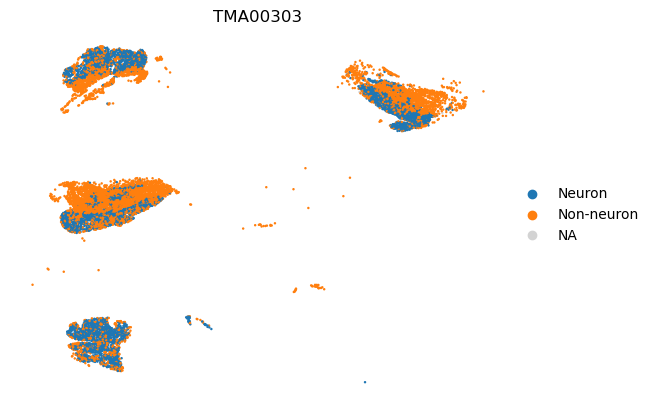

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


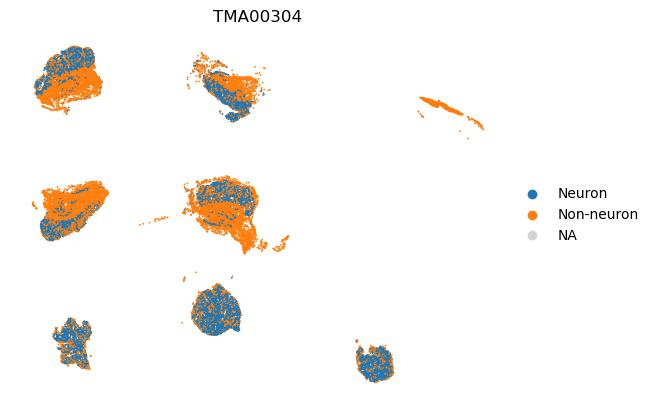

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


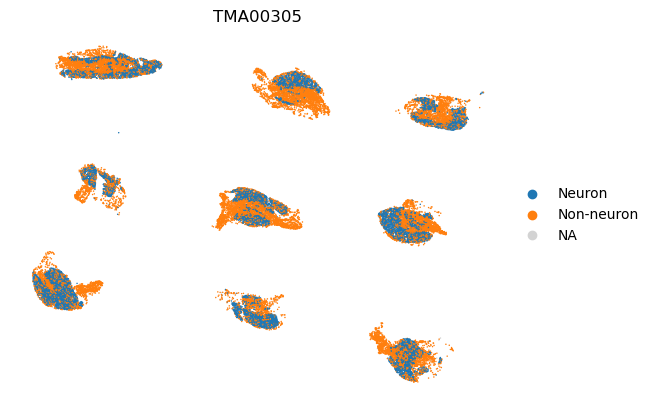

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


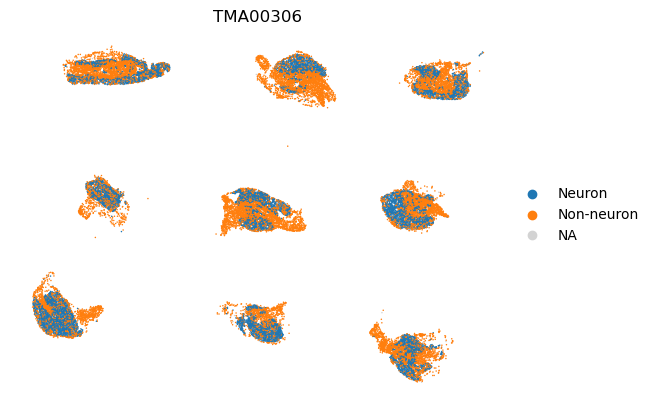

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


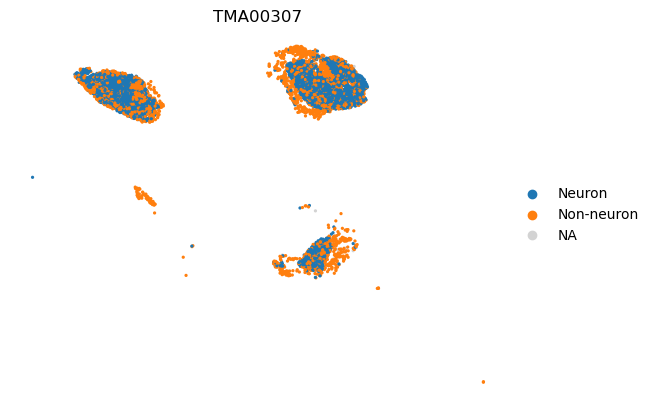

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


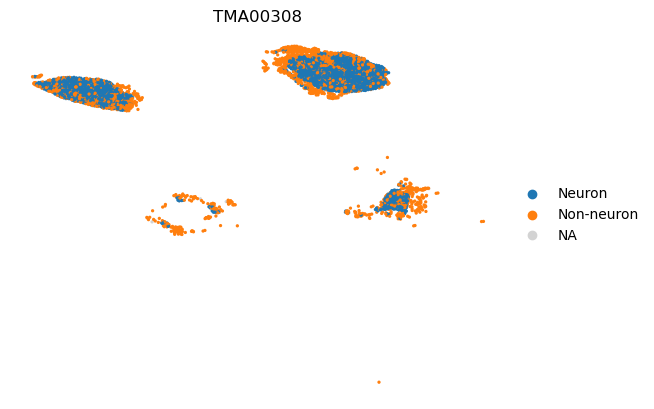

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


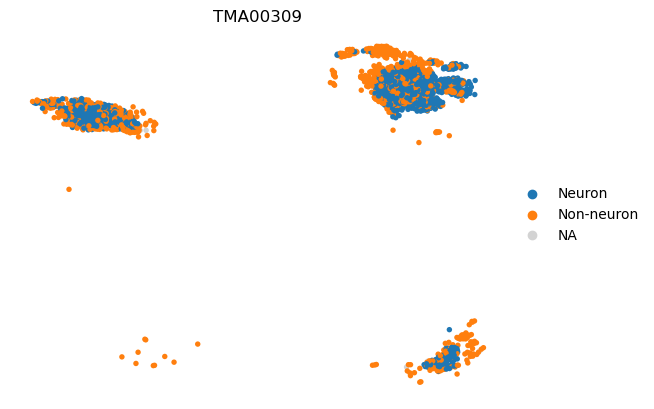

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


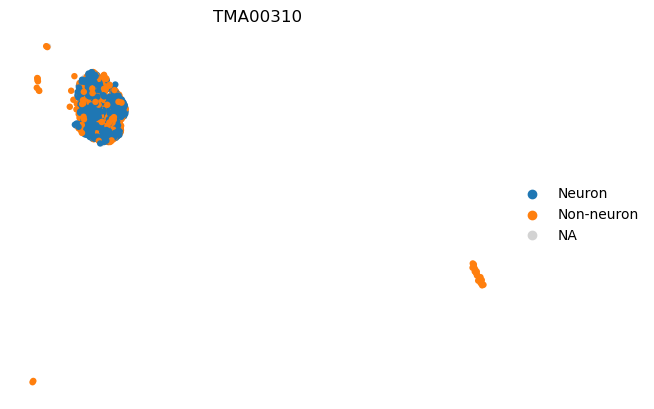

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


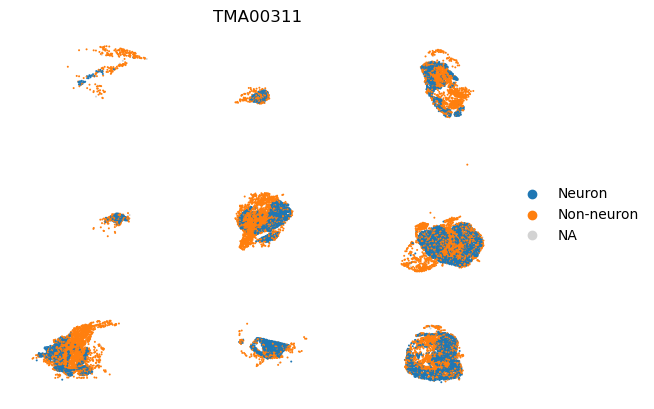

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


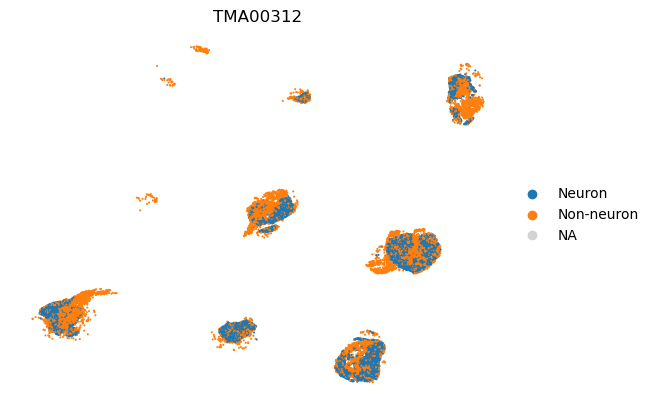

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


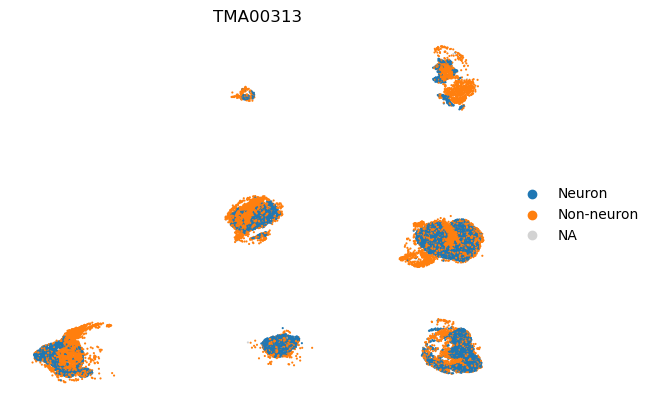

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


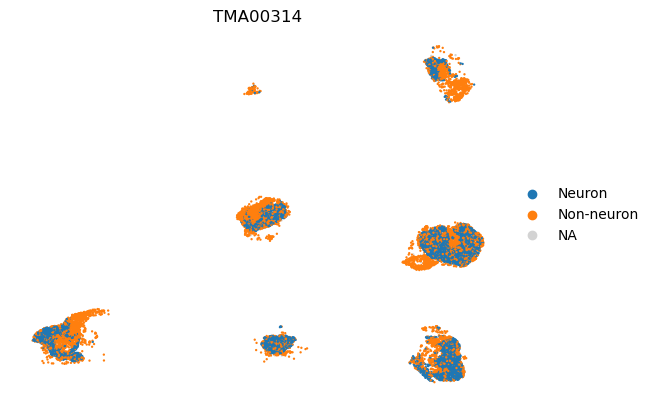

In [31]:
for sample in adata_global.obs['sample_id'].cat.categories:
    adata_sample = adata_global[adata_global.obs['sample_id']==sample, :].copy()
    sc.pl.embedding(adata_sample, basis = 'spatial', color = 'seurat_class', frameon=False, title = sample)

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values

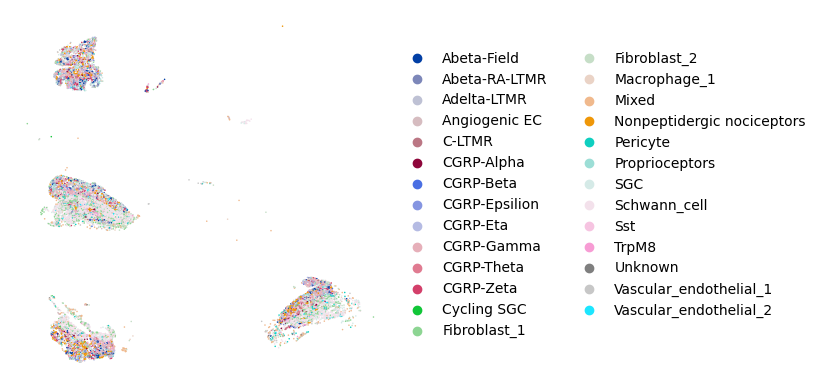

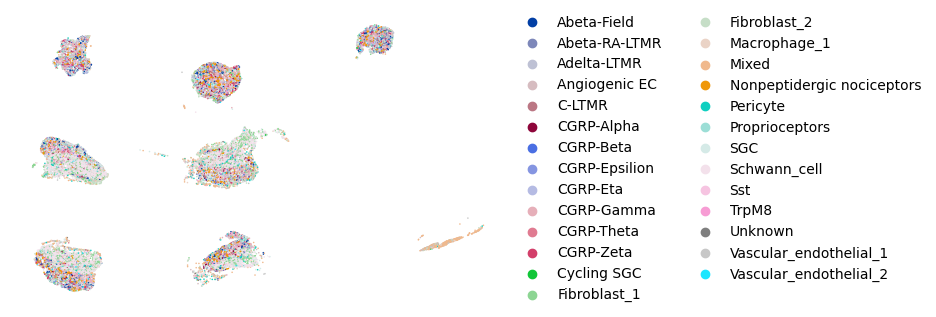

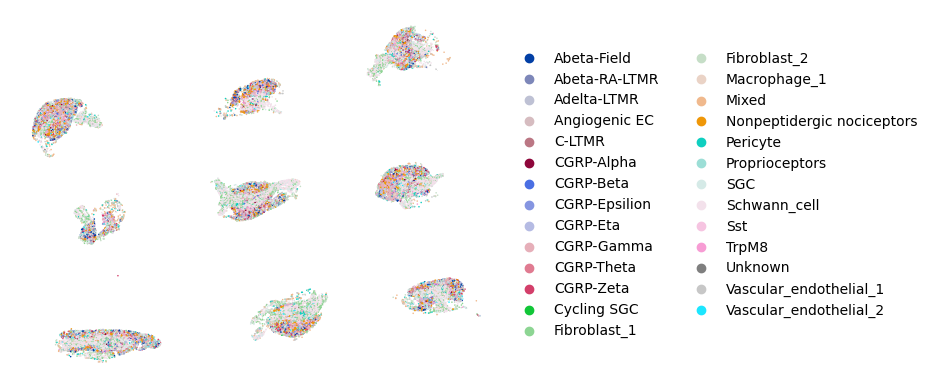

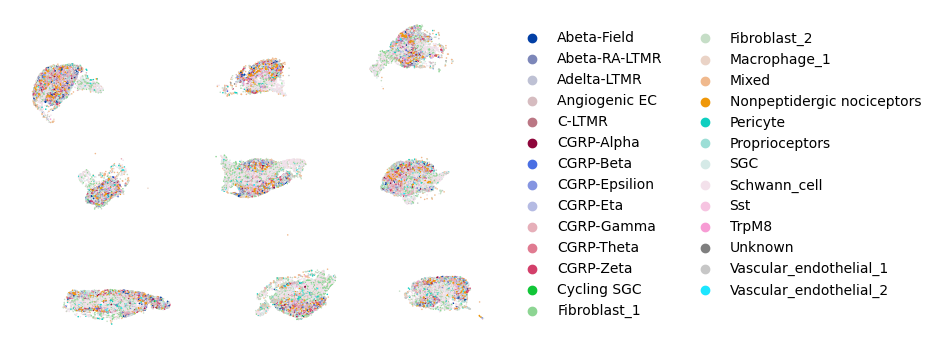

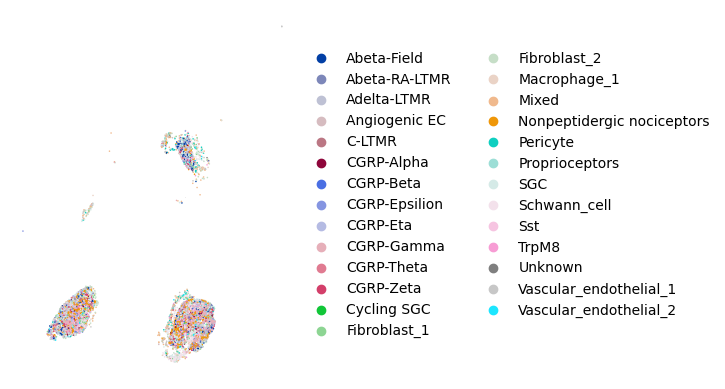

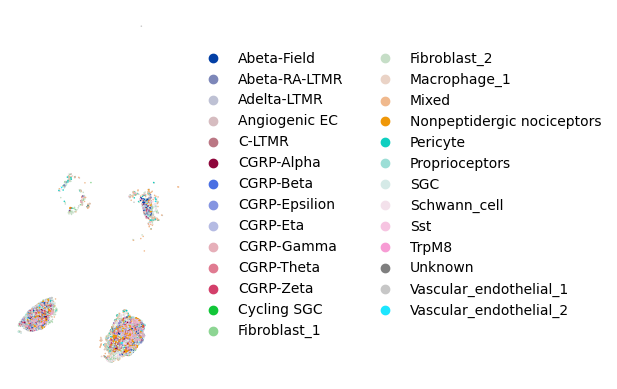

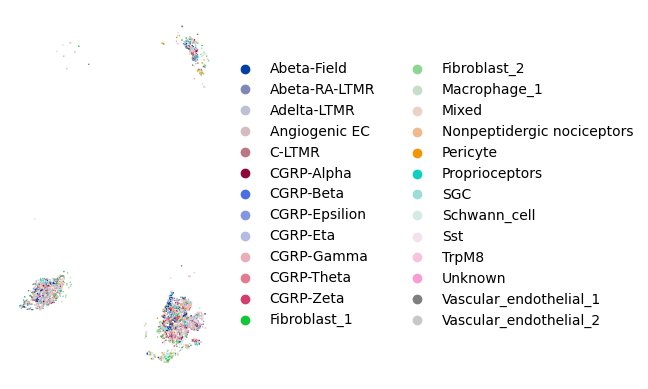

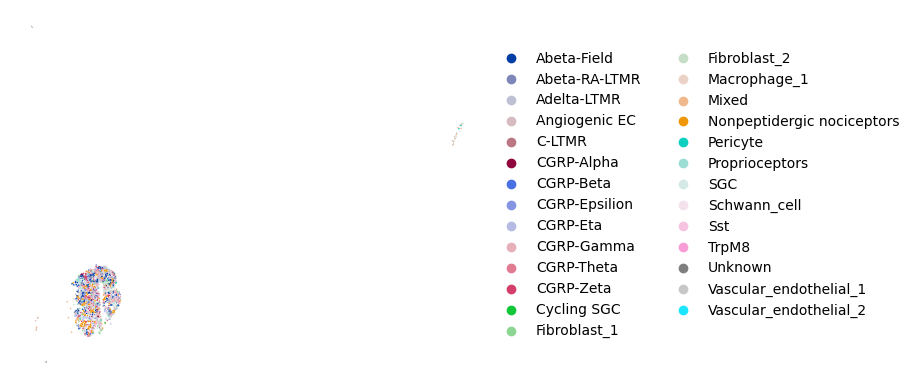

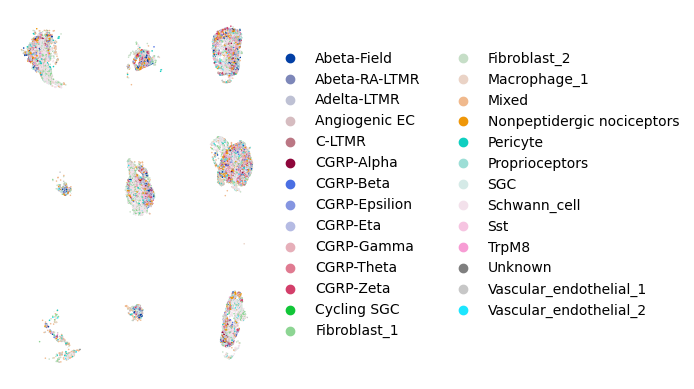

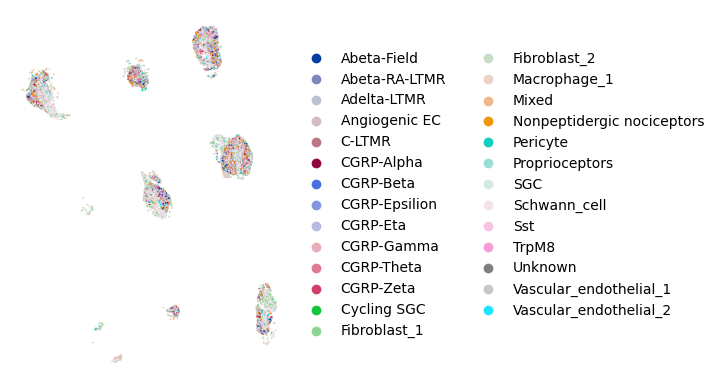

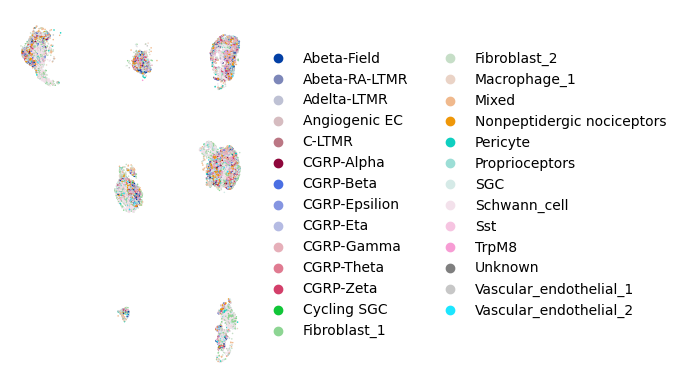

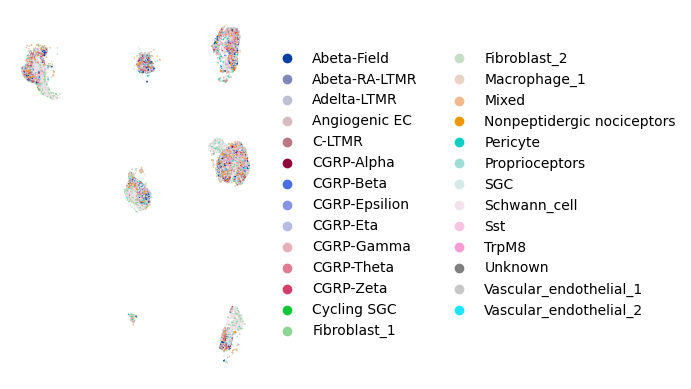

In [32]:
sample = 'TMA00312'
for sample in adata_global.obs['sample_id'].cat.categories:
    adata_sample = adata_global[adata_global.obs['sample_id']==sample, :].copy()
    plot_neuron_zoom(
        adata_sample, 
        label_col = 'seurat_labels',
        # label_col = 'neuron_label',
        # palette=neuron_label_palette_mapped,
        spot_size_labeled=5, 
                         spot_size_bg=1
    )

## Outline each DRG

I want to idenitfy the edge of each DRG and calculat the distance of each neuron to the edge. From the quick look at the DRG tissues above, there are a few consdierations to take into account.
- Some tissues look like just partial DRGs, where only a small amount of tissue is present. We can exclude these by requiring a minimum size of the DRG

We'll try drawing a convex hull around each DRG and then use the shape for distance calculations.

In [178]:
### Draw a convex hull around each DRG 

In [179]:
import scipy
from scipy.sparse import csr_matrix
from scipy.spatial import distance_matrix
from scipy.spatial.distance import cdist
from scipy import stats
import scipy.ndimage as ndi
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks

from shapely.geometry import Point
from shapely.geometry import Polygon, MultiPolygon
from alphashape import alphashape
from alphashape import optimizealpha
import geopandas as gpd
import math
import joblib


def get_alphashape(adata, zone_column, zone_id, alpha):
    """
    Computes and plots the alpha shape (concave hull) around spatial coordinates of selected zones.

    Returns:
        shapely.MultiPolygon: Alpha shape geometry of the selected cells.
    """
    
    # get alphashape masks
    adata.obs['highlight'] = adata.obs[zone_column].isin(zone_id)
    mask = adata.obs['highlight']
    spatial_key = 'spatial' if 'spatial' in adata.obsm else 'X_spatial'
    spatial_coords = adata.obsm[spatial_key][mask, :]
    alpha_shape = alphashape(spatial_coords, alpha=alpha)

    # Force the output into a MultiPolygon (robust to when only one shape identified)
    if isinstance(alpha_shape, Polygon):
        alpha_shape = MultiPolygon([alpha_shape])
    elif not isinstance(alpha_shape, MultiPolygon):
        # Handles cases where alpha_shape might be a Point or None
        return MultiPolygon()

    # plot initial masks and borders
    fig, ax = plt.subplots(1,1, figsize=(8,6))
    ax.scatter(spatial_coords[:, 0], spatial_coords[:, 1], s=0.1, color='gray')
    # Add the MultiPolygon to the plot
    for p in alpha_shape.geoms:
        ax.plot(*p.exterior.xy, c='black')
    ax.set_title('Initial alpha shapes borders')

    return alpha_shape

def get_shape_axes(geometry):
    """
    Calculates the minor and major axes of a polygon using its minimum bounding rectangle.

    Returns:
        tuple: (minor_axis, major_axis) lengths.
    """
    
    # Get the minimum bounding rectangle (MBR)
    mbr = geometry.minimum_rotated_rectangle
    
    # Extract the coordinates of the MBR
    mbr_coords = np.array(mbr.exterior.coords)
    
    # Calculate the width and height of the MBR
    edge1 = np.linalg.norm(mbr_coords[0] - mbr_coords[1])
    edge2 = np.linalg.norm(mbr_coords[1] - mbr_coords[2])

    minor_axis = min(edge1, edge2)
    major_axis = max(edge1, edge2)

    return minor_axis, major_axis


def process_alphashape(alpha_shape, adata, zone_column, zone_id, area_threshold = None, circularity_threshold = None):
    """
    Filters, smooths, and visualizes alpha shapes for given zones and extracts geometric metrics.

    Returns:
        tuple: (MultiPolygon of filtered shapes, GeoDataFrame of shape metrics).
    """
    
    # Get spatial coords
    adata.obs['highlight'] = adata.obs[zone_column].isin(zone_id)
    mask = adata.obs['highlight']
    spatial_key = 'spatial' if 'spatial' in adata.obsm else 'X_spatial'
    spatial_coords = adata.obsm[spatial_key][mask, :]
    
    # filter based on size
    
    # first plot histogram of sizes
    areas = [geometry.area for geometry in alpha_shape.geoms]
    plt.figure(figsize=(8, 6))
    plt.hist(areas, bins=100, color='skyblue', edgecolor='black')
    if area_threshold:
        plt.axvline(x=area_threshold, color='red', linestyle='--', linewidth=1)
    plt.title('Areas')
    plt.show()

    # filter based on area threshold
    if area_threshold:
        shapes = MultiPolygon([poly for poly in alpha_shape.geoms if poly.area >= area_threshold])
    else:
        shapes = alpha_shape

    # smooth
    shapes_smooth = MultiPolygon(
        # [p.buffer(30, join_style=1).buffer(-20.0, join_style=1) for p in shapes.geoms]
        [p.buffer(20, join_style=1).buffer(-20.0, join_style=1) for p in shapes.geoms]
    )
 
    # plot with all steps
    fig, ax = plt.subplots(1,1, figsize=(8,6))
    ax.scatter(spatial_coords[:, 0], spatial_coords[:, 1], s=0.1, color='gray')
    # Original border
    for p in alpha_shape.geoms:
        ax.plot(*p.exterior.xy, c='black')
    # Size filtered
    for p in shapes.geoms:
        ax.plot(*p.exterior.xy, c='red')
    # smoothed
    for p in shapes_smooth.geoms:
        ax.plot(*p.exterior.xy, c='green')
    ax.set_title('Smoothed, size filtered shape borders')

    # generate GeoPandas dataframe for export
    shape_list = []
    for i, shape in enumerate(shapes_smooth.geoms):
        shape_list.append({'id': i, 'geometry': shape})
        
    shape_gdf = gpd.GeoDataFrame(shape_list)
    shape_gdf['area'] = shape_gdf['geometry'].area
    shape_gdf['perimeter'] = shape_gdf['geometry'].exterior.length
    shape_gdf['circularity'] = 4*math.pi * shape_gdf['geometry'].area / (shape_gdf['geometry'].exterior.length)**2  
    shape_gdf[['minor_axis', 'major_axis']] = shape_gdf.apply(lambda row: pd.Series(get_shape_axes(row['geometry'])), axis=1)

    # return both the multipolygon object and the dataframe
    return shapes_smooth, shape_gdf

# Plot shape characteristics - one at a time
def plot_shape_metric_single(gdf, metric, save_path=None):
    """
    Plots a single shape metric as a strip and boxplot.

    Args:
        gdf (GeoDataFrame): DataFrame with shape metrics.
        metric (str): Column name of the metric to plot.
        save_path (str, optional): File path to save the plot.
    """
    
    fig, ax = plt.subplots(1,1, figsize=(2,4))
    sns.stripplot(data=gdf, y=metric, ax=ax, alpha = 0.5, size=2)
    ax.boxplot(gdf[metric], positions=[0], showfliers=False)
    # Set labels and title
    ax.set_xticks([0])
    ax.set_xticklabels([metric])
    ax.set_ylabel('microns')


# Plot shape characteristics - multiple
def plot_shape_metrics(gdf, columns, save_path=None):
    """
    Plots multiple shape metrics side by side as strip and boxplots.

    Args:
        gdf (GeoDataFrame): DataFrame with shape metrics.
        columns (list): List of metric column names to plot.
        save_path (str, optional): File path to save the combined plot.
    """   
    n_plots = len(columns)
    fig, axs = plt.subplots(1, n_plots,
                                # sharex = True, sharey = True,
                                figsize=(n_plots*2, 4)
                               )
    
    for plot_num, metric in enumerate(columns):
        ax = axs[plot_num]
        sns.stripplot(data=gdf, y=metric, ax=ax, alpha = 0.5, size=2)
        ax.boxplot(gdf[metric], positions=[0], showfliers=False)
        ax.set_xticks([0])
        ax.set_xticklabels([metric])
        ax.set_ylabel('microns')

    plt.subplots_adjust(wspace=1)

    if save_path:
        fig.savefig(save_path)
        

def add_structure_info_to_adata(adata, structure_gdf, structure_name, sample, out_dir):

    index_col = 'index'
    area_col = 'area'

    # add geometry / structure centroid
    structure_gdf['centroid_x'] = structure_gdf['geometry'].centroid.x
    structure_gdf['centroid_y'] = structure_gdf['geometry'].centroid.y
    
    # x y points for each cell 
    points_df = pd.DataFrame(adata_sample.obs[['x_centroid','y_centroid']])
    points_gdf = gpd.GeoDataFrame(points_df, geometry=gpd.points_from_xy(points_df.x_centroid, points_df.y_centroid))
    
    # Perform a spatial join to check if geometries contain any points
    joined_gdf = gpd.sjoin(points_gdf, structure_gdf, how="left", predicate="within")

    # add ID and area as columns in adata.obs 
    joined_gdf = joined_gdf[~joined_gdf.index.duplicated(keep='first')]
    joined_gdf = joined_gdf.rename(columns={'id': index_col, 'area': area_col})
    joined_gdf[index_col] = joined_gdf[index_col].astype('category')

    # save id / area to csv
    structure_id_df = pd.DataFrame(joined_gdf[[index_col, area_col, 'centroid_x', 'centroid_y']])
    structure_id_df.to_csv(os.path.join(out_dir, sample + '_' + structure_name + '_id_df.csv'), index=True)

    return structure_id_df 

In [222]:
def plot_spatial_zoom_polys(adata, color_col = 'neuron_label', label_celltypes=None, polygons=None, 
        x_lims=None, y_lims=None, invert_y = True,
        palette=None, cmap = None, bg_color='lightgray', 
        size=80, size_bg=20, alpha = 1, alpha_bg = 1):
    """
    Plots a zoomed-in spatial view with highlighted cell types and a grey background.
    """
    # 1. Setup Figure
    fig, ax = plt.subplots()
    
    # 2. Handle Logic for Labeled vs Unlabeled
    if label_celltypes:
        # Layer 1: The background (Other cells)
        # We use .copy() to avoid ImplicitModificationWarning
        adata_bg = adata[~adata.obs[color_col].isin(label_celltypes), :].copy()
        adata_bg.obs['bg_color'] = 'background'
        
        sc.pl.embedding(
            adata_bg, basis='spatial', color='bg_color', 
            palette={'background': bg_color}, cmap = cmap, size=size_bg, alpha = alpha_bg,
            show=False, frameon=False, title='', ax=ax, legend_loc = 'none'
        )
        
        # Layer 2: The high-quality neurons (Highlighted)
        adata_labeled = adata[adata.obs[color_col].isin(label_celltypes), :].copy()
        sc.pl.embedding(
            adata_labeled, basis='spatial', color=color_col, 
            palette=palette, cmap = cmap, size=size, alpha = alpha,
            show=False, frameon=False, title='', ax=ax
        )
    else:
        # Default behavior: Plot all non-NaN neurons colored, NaNs as grey
        adata_neurons = adata[~adata.obs[color_col].isna(), :].copy()
        sc.pl.embedding(
            adata_neurons, basis='spatial', color=color_col, 
            palette=palette, cmap = cmap, size=size, alpha = alpha,
            show=False, frameon=False, title='', ax=ax
        )
        
        adata_nan = adata[adata.obs[color_col].isna(), :].copy()
        sc.pl.embedding(
            adata_nan, basis='spatial', color=color_col, 
            palette=palette, cmap = cmap, size=size_bg, alpha = alpha_bg,
            show=False, frameon=False, title='', ax=ax, legend_loc = 'none', colorbar_loc = None
        )

    if polygons is not None:
        # If the user passed a single object, wrap it in a list with a default color
        if not isinstance(polygons, list):
            polygons = [(polygons, 'black')]
            
        for poly_obj, c in polygons:
            # Handle MultiPolygon (geoms) vs single Polygon
            geoms = poly_obj.geoms if hasattr(poly_obj, 'geoms') else [poly_obj]
            for p in geoms:
                ax.plot(*p.exterior.xy, color=c, linewidth=2)

    # 3. Apply Zoom and Aspect Ratio
    ax.set_aspect('equal', adjustable='box')
    
    if x_lims:
        ax.set_xlim(x_lims)
    if y_lims:
        ax.set_ylim(y_lims)
    
    if invert_y:
        ax.invert_yaxis()
    
    return fig, ax





# def plot_spatial_zoom_polys(adata, basis='spatial', color='seurat_class', palette=None, cmap = None, 
#                       polygons=None, x_lims=None, y_lims=None, 
#                       invert_y=True, size=5, alpha=0.5, title=''):
#     """
#     Plots a spatial embedding with optional polygon overlays and custom zoom.
    
#     Parameters:
#     - polygons: List of tuples [(poly_obj, 'color'), ...]
#     - x_lims/y_lims: List or tuple of [min, max]
#     """
#     # Generate the base embedding plot
#     ax = sc.pl.embedding(
#         adata, basis=basis, color=color, palette=palette, cmap = cmap,
#         title=title, frameon=False, size=size, alpha=alpha, show=False
#     )
    
#     if polygons is not None:
#             # If the user passed a single object, wrap it in a list with a default color
#             if not isinstance(polygons, list):
#                 polygons = [(polygons, 'black')]
                
#             for poly_obj, c in polygons:
#                 # Handle MultiPolygon (geoms) vs single Polygon
#                 geoms = poly_obj.geoms if hasattr(poly_obj, 'geoms') else [poly_obj]
#                 for p in geoms:
#                     ax.plot(*p.exterior.xy, color=c, linewidth=2)
                
#     # Set aspect ratio and zoom
#     ax.set_aspect('equal', adjustable='box')
#     if x_lims:
#         ax.set_xlim(x_lims)
#     if y_lims:
#         ax.set_ylim(y_lims)
        
#     # 4. Handle Y-Axis Inversion
#     # Xenium data usually requires inversion for correct orientation
#     if invert_y:
#         ax.invert_yaxis()
        
#     plt.show()
#     return ax

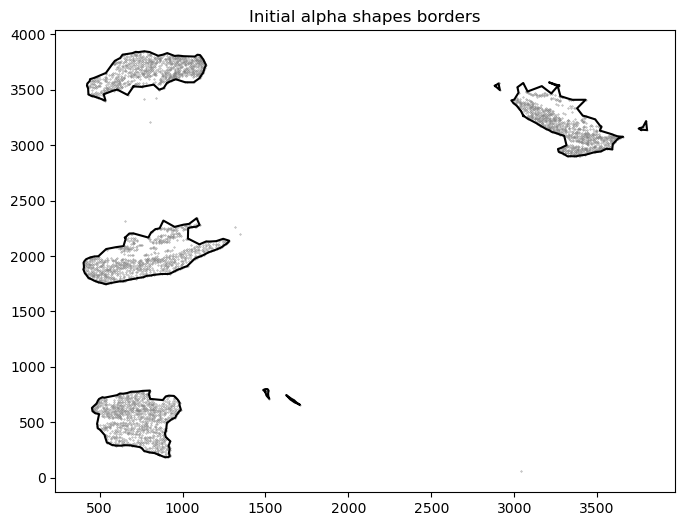

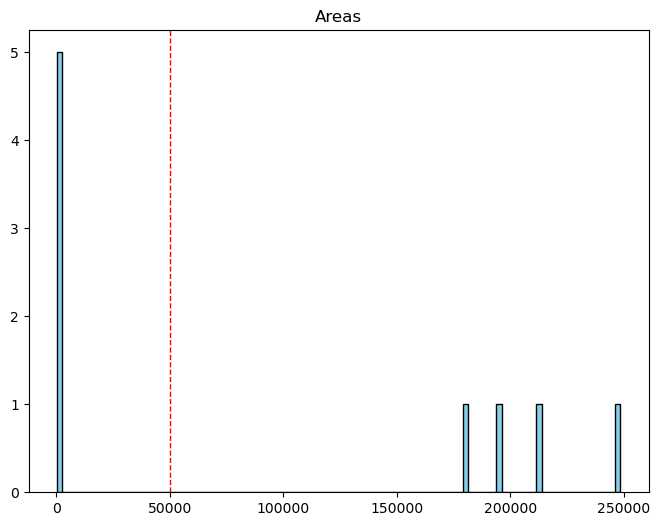

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


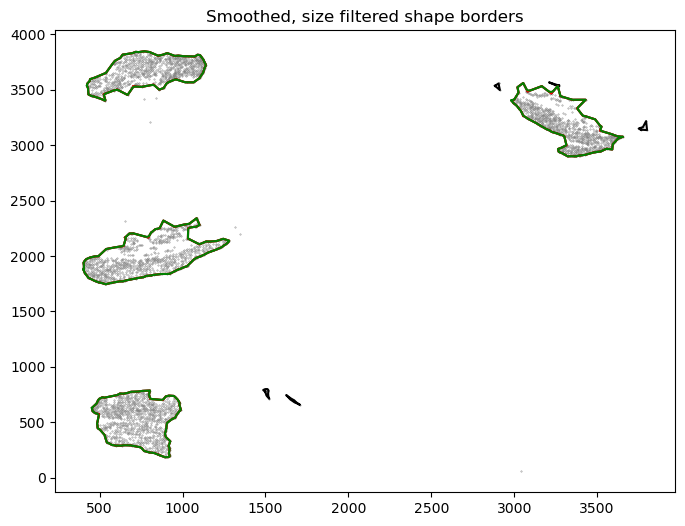

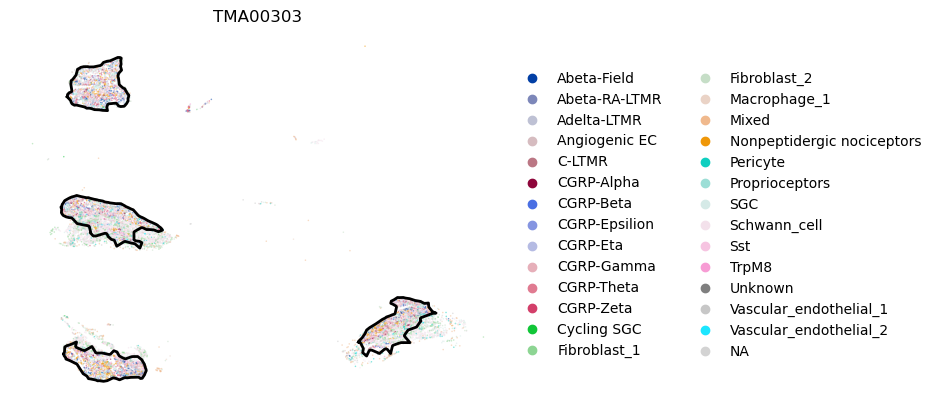

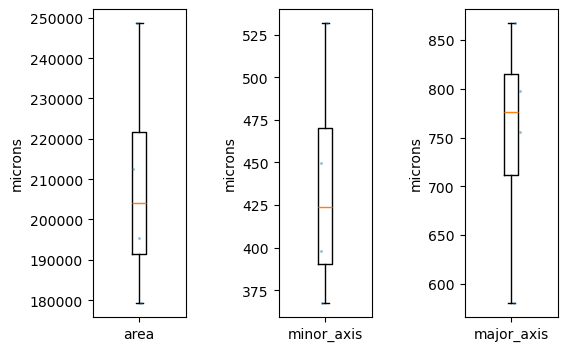

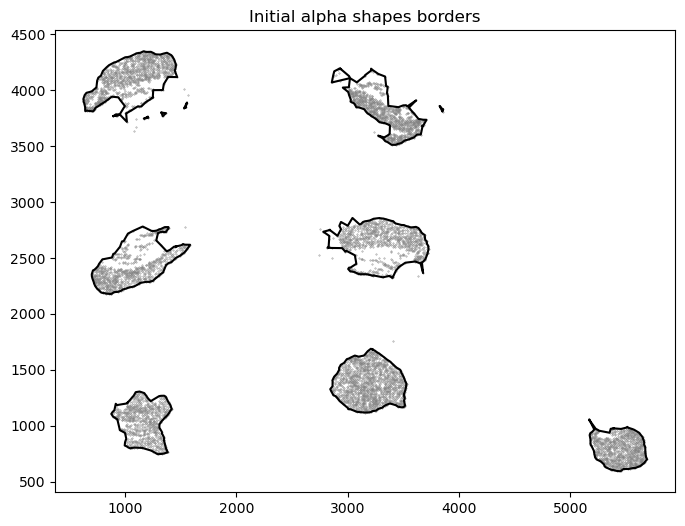

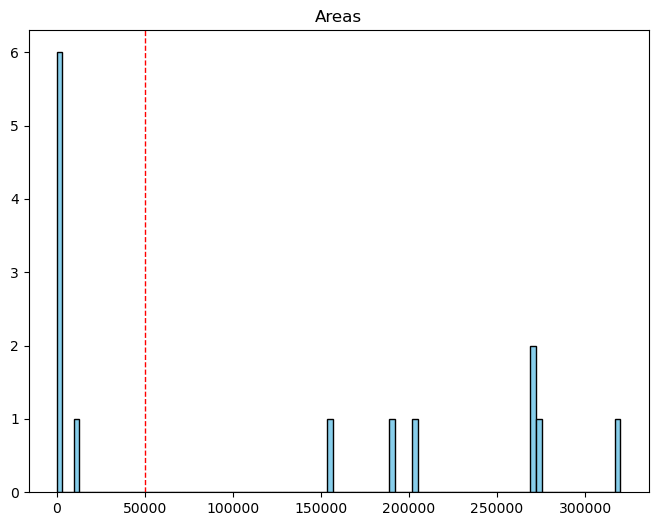

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


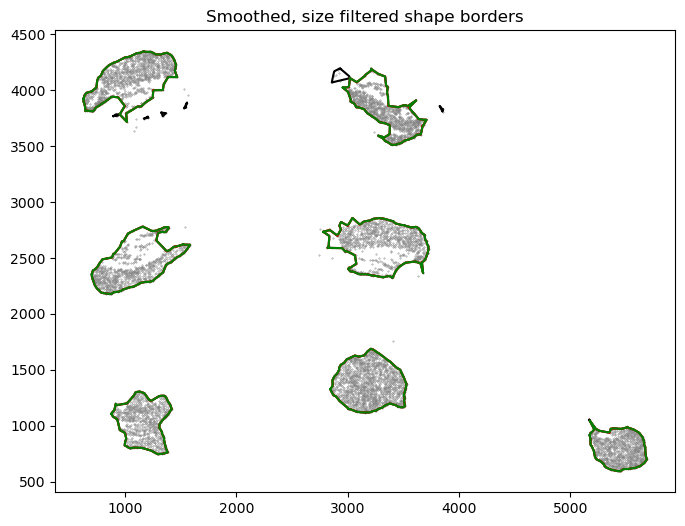

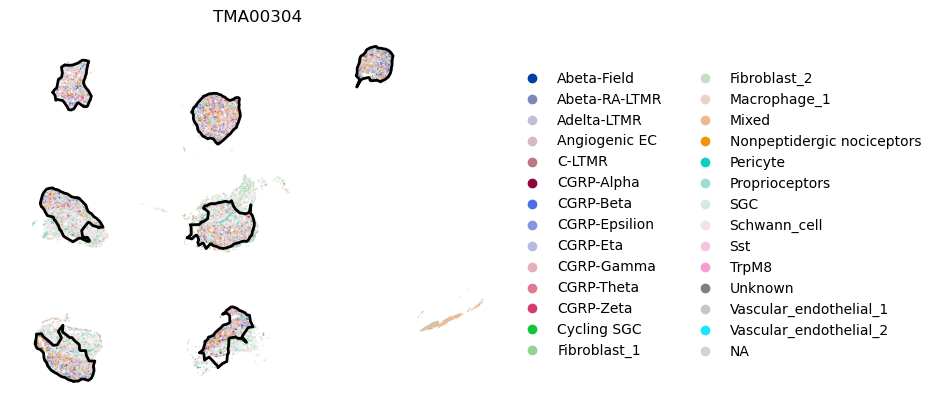

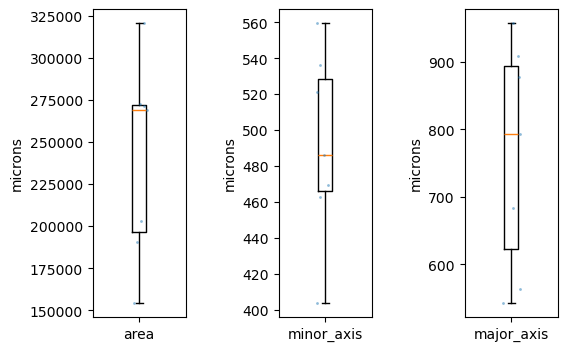

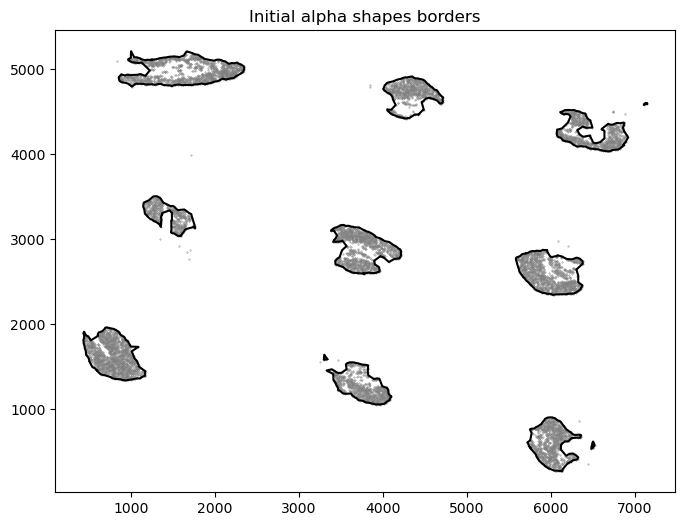

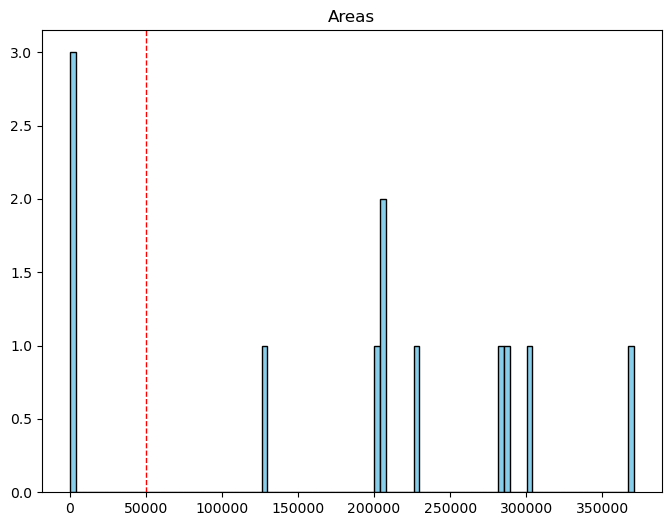

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


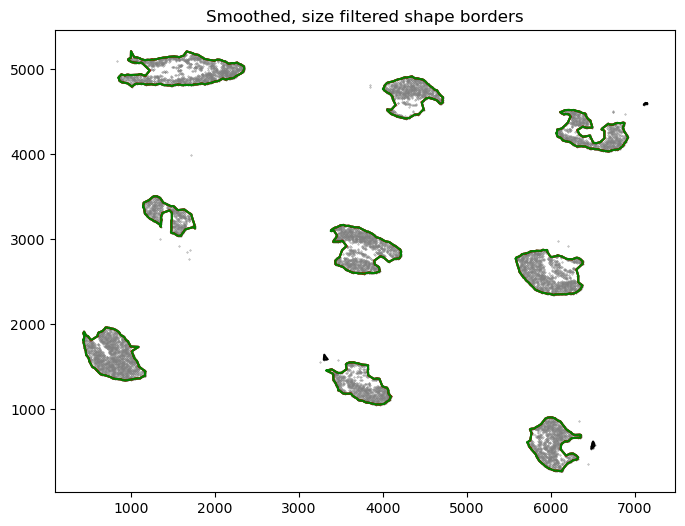

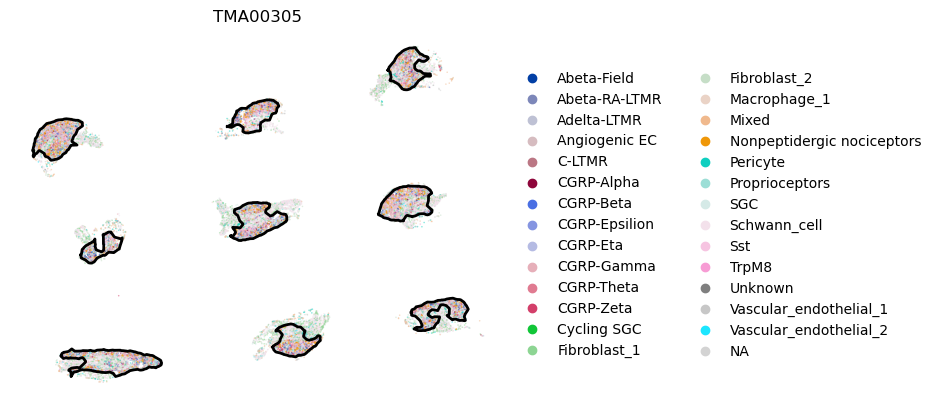

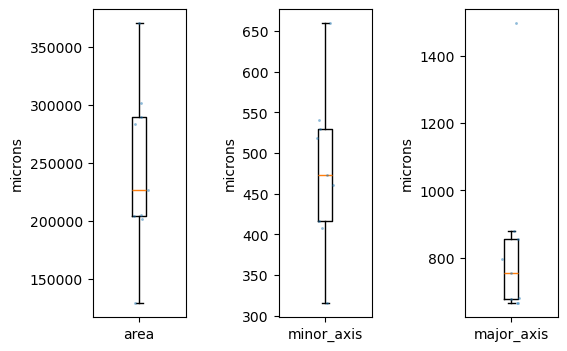

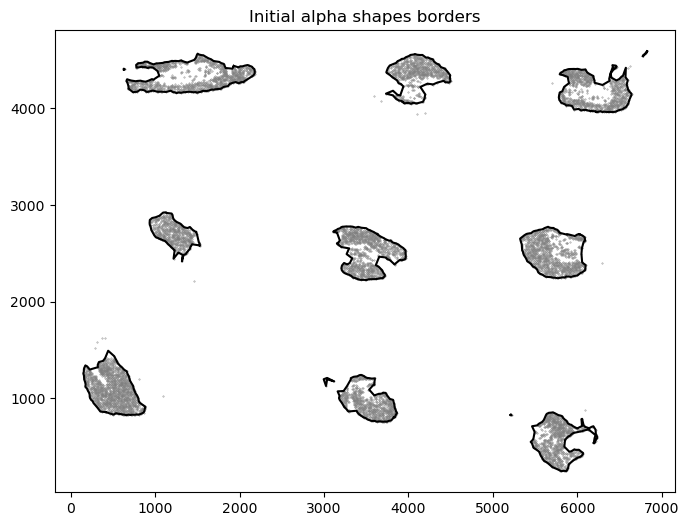

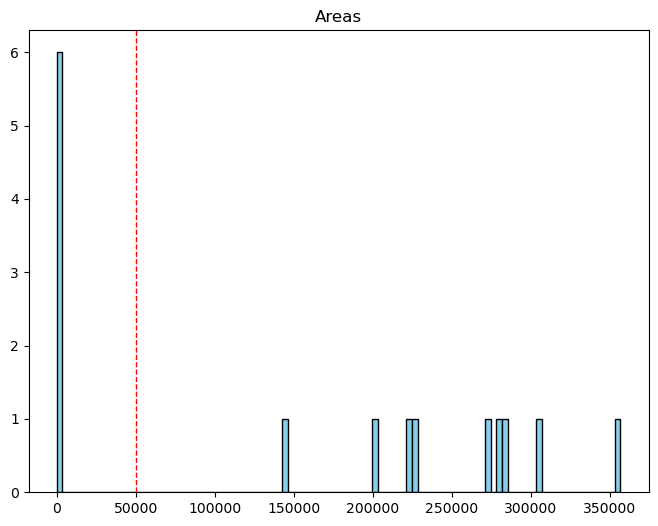

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


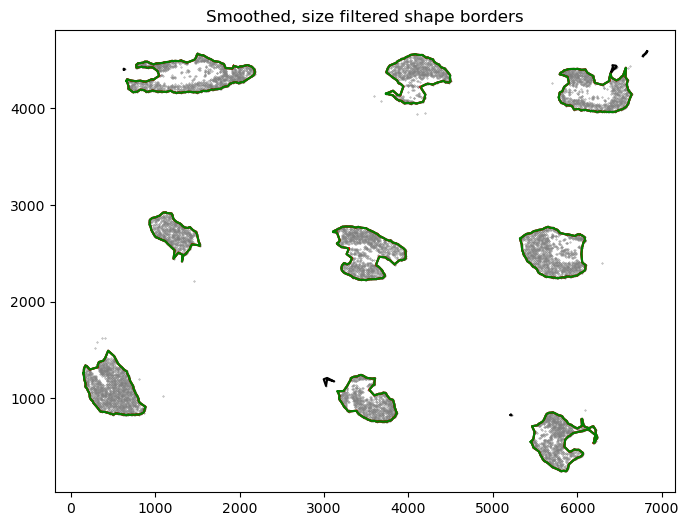

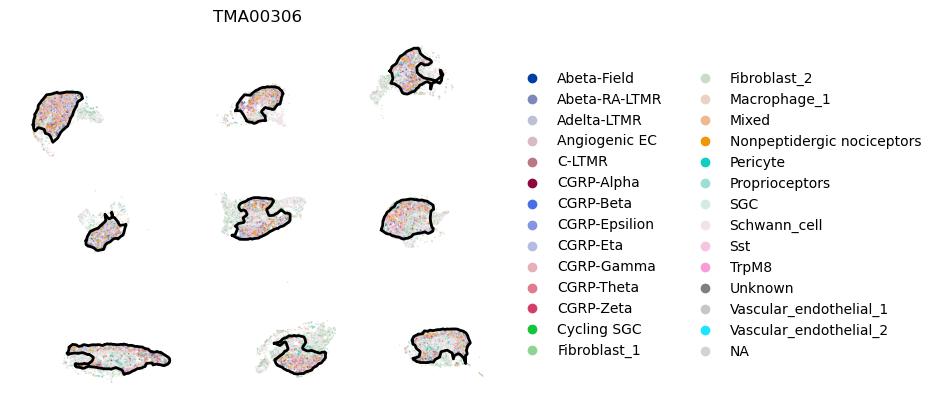

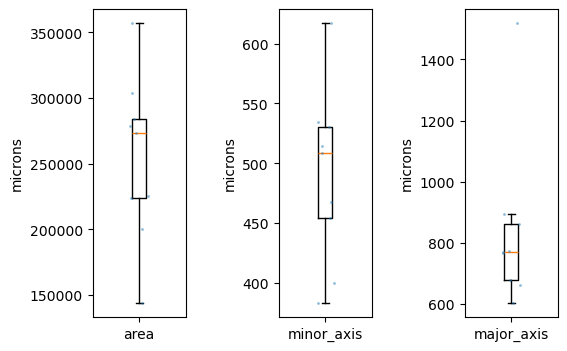

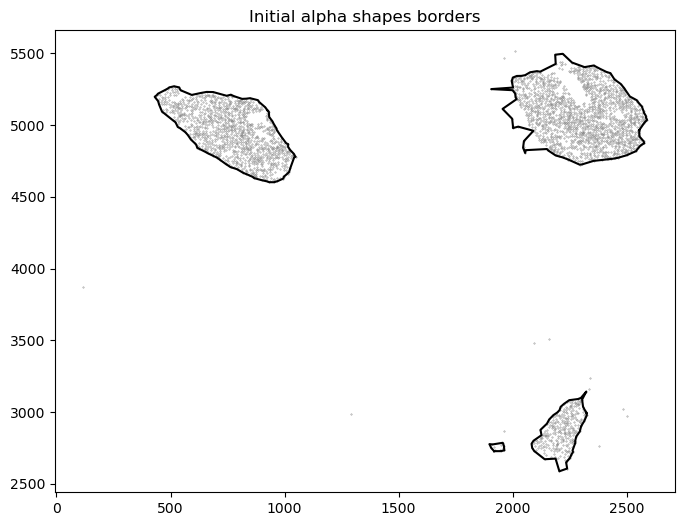

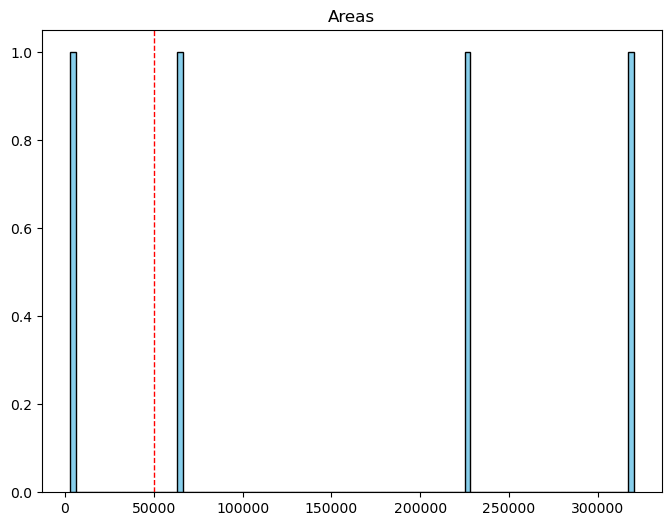

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


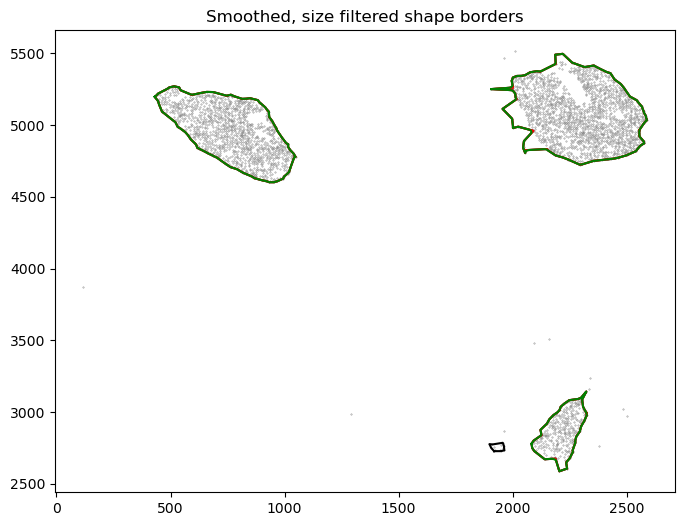

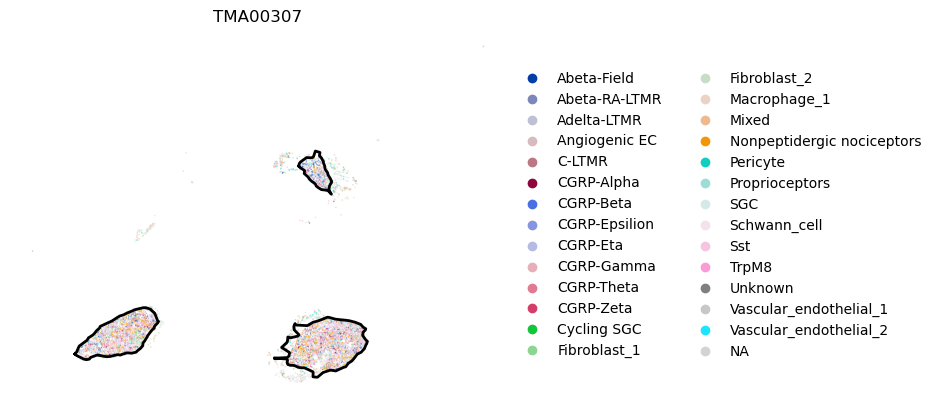

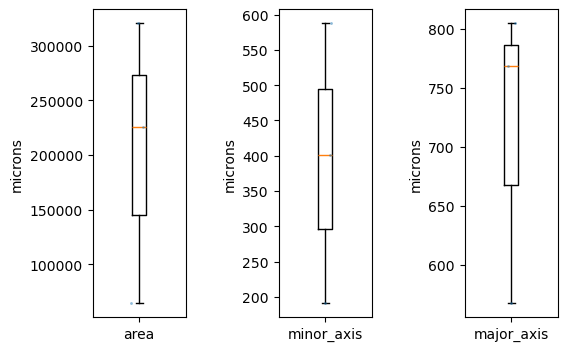

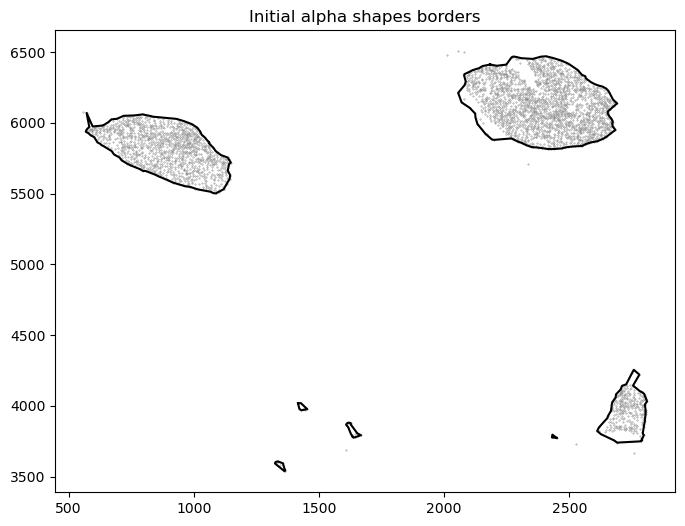

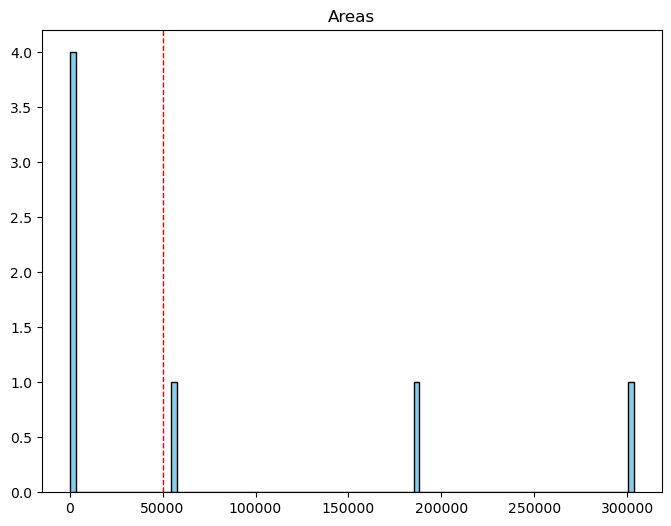

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


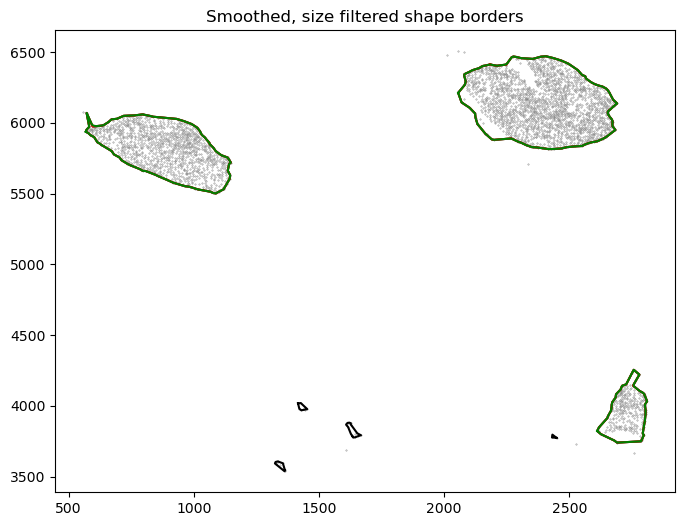

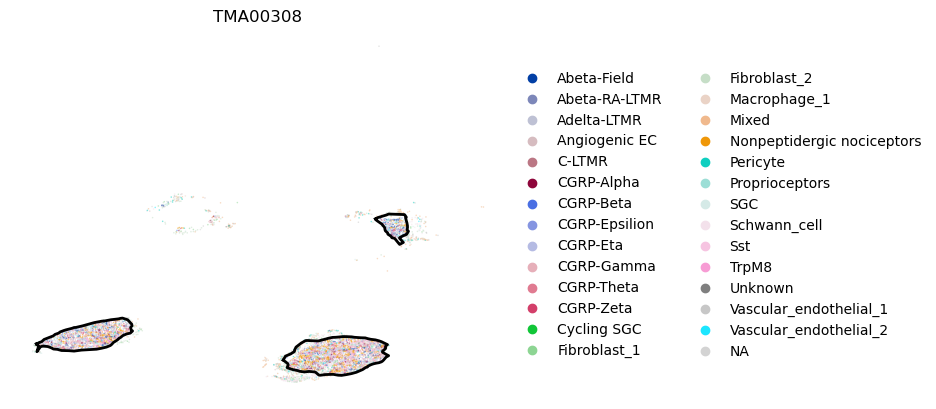

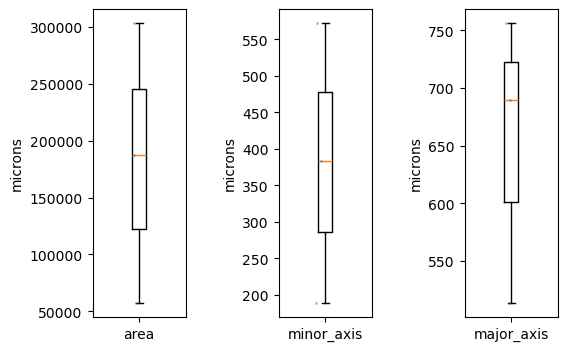

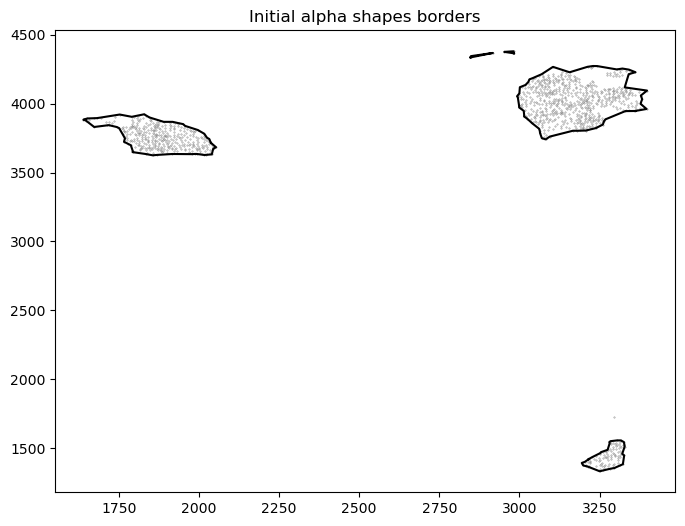

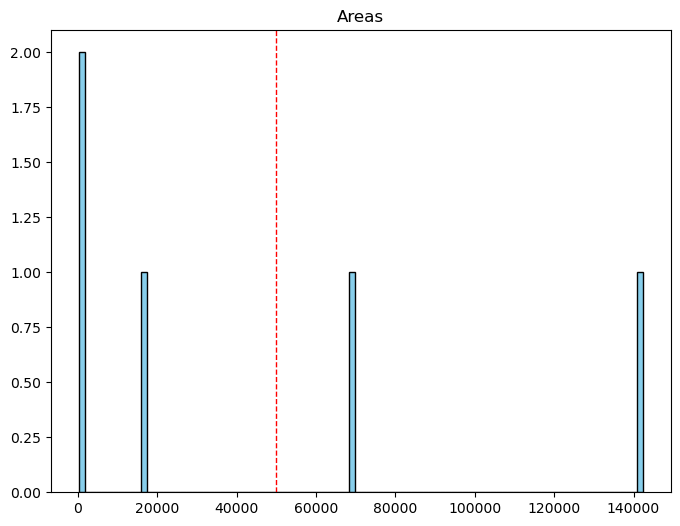

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


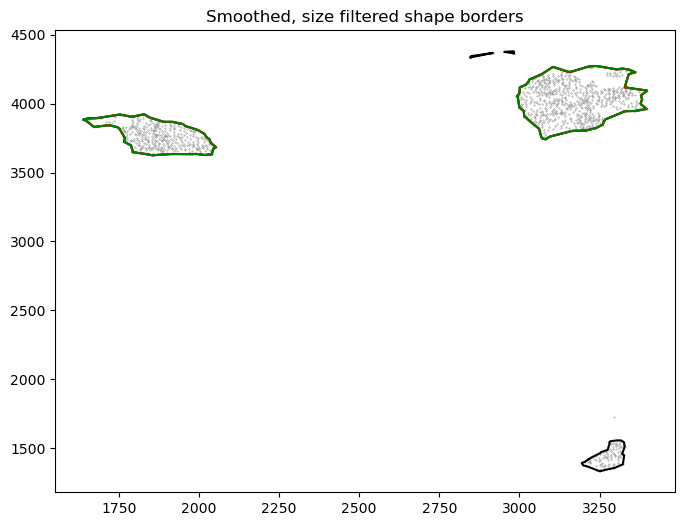

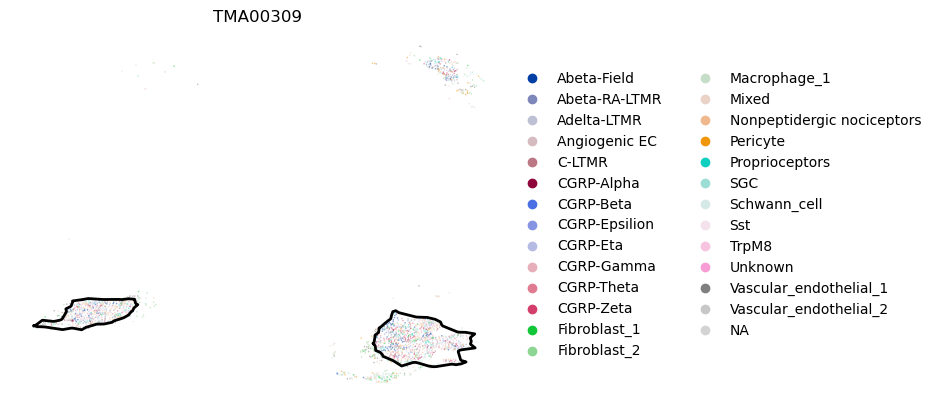

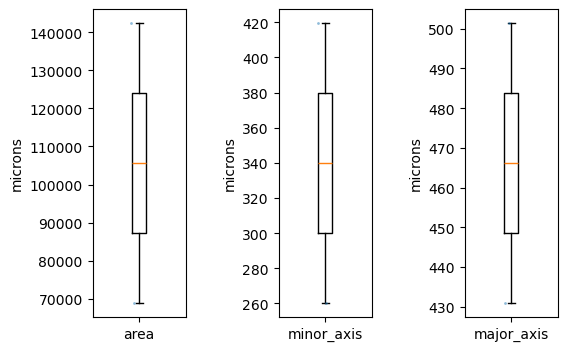

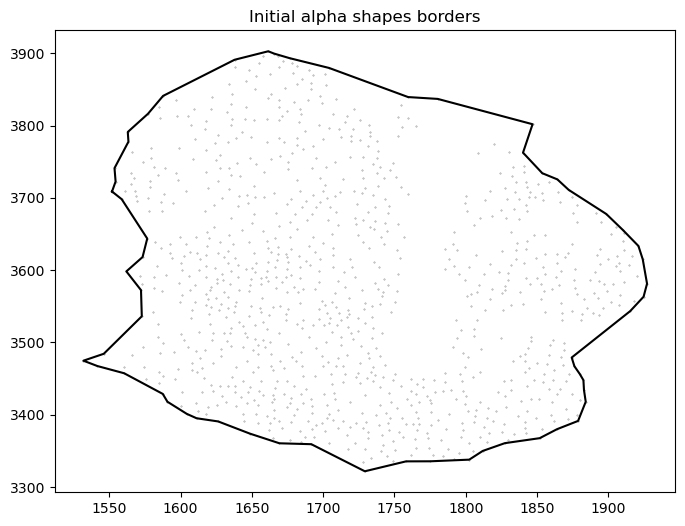

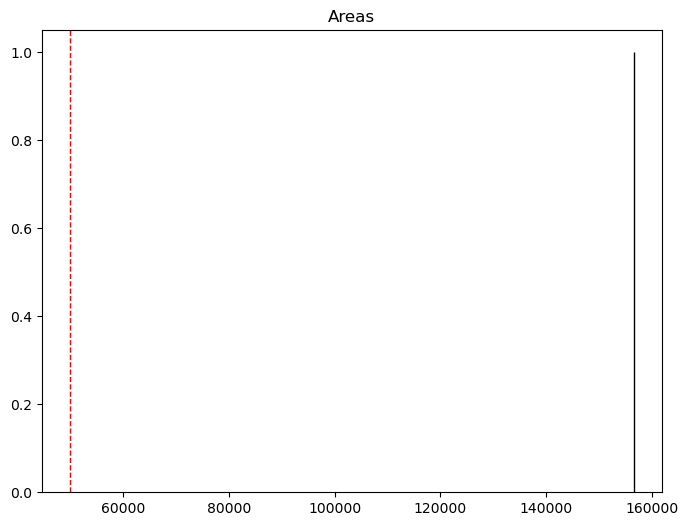

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


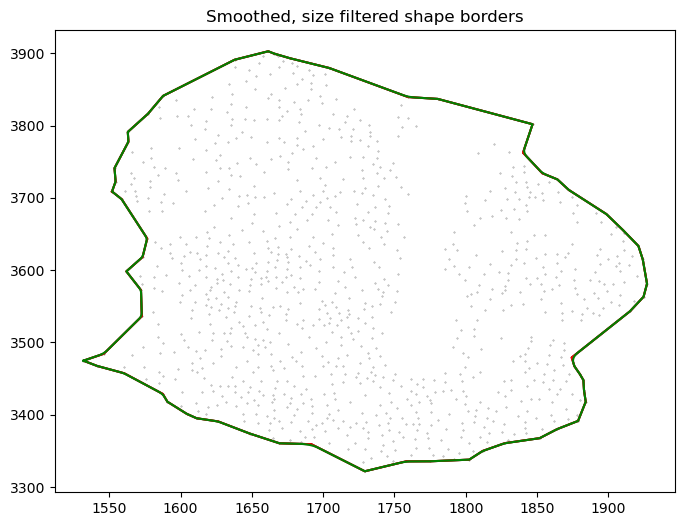

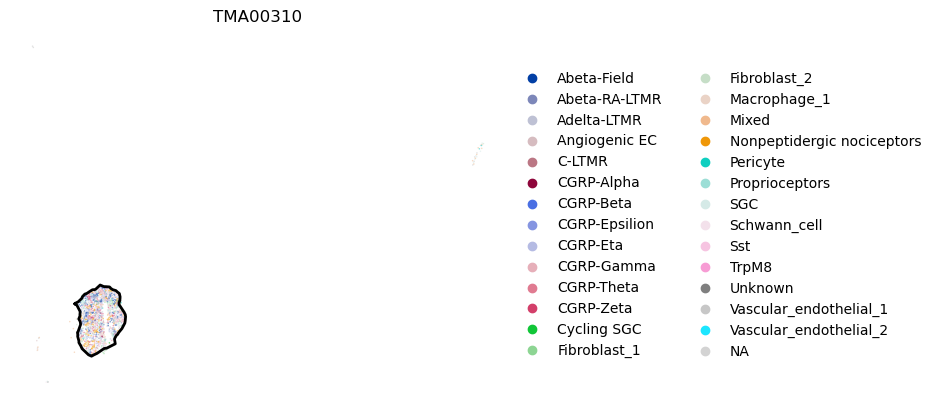

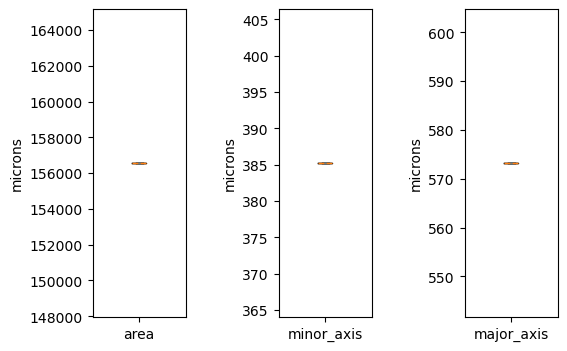

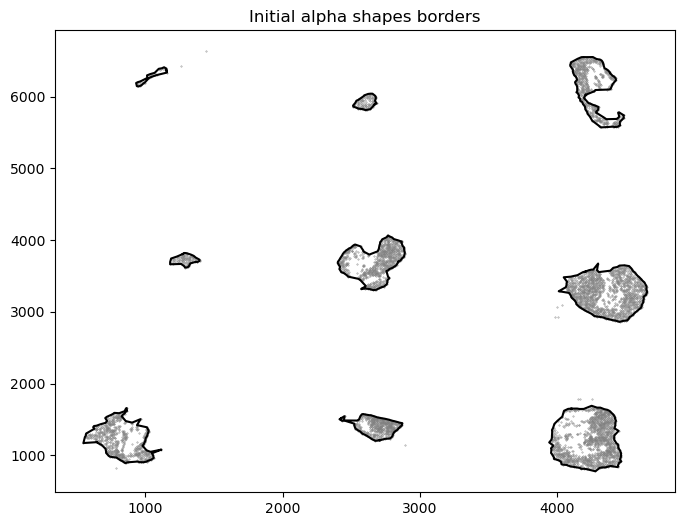

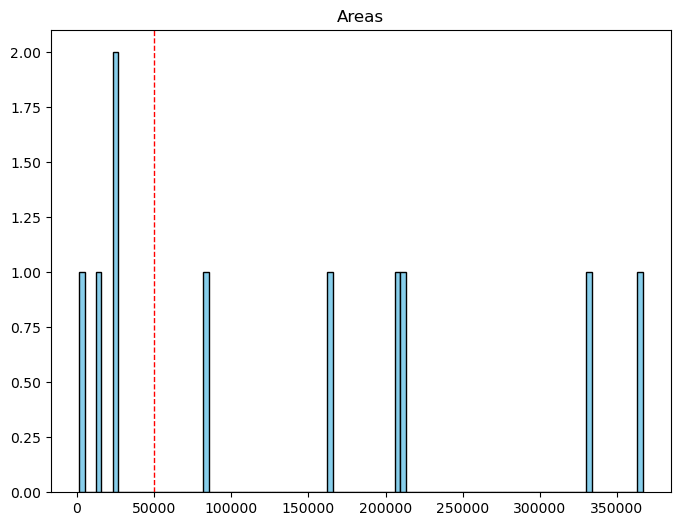

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


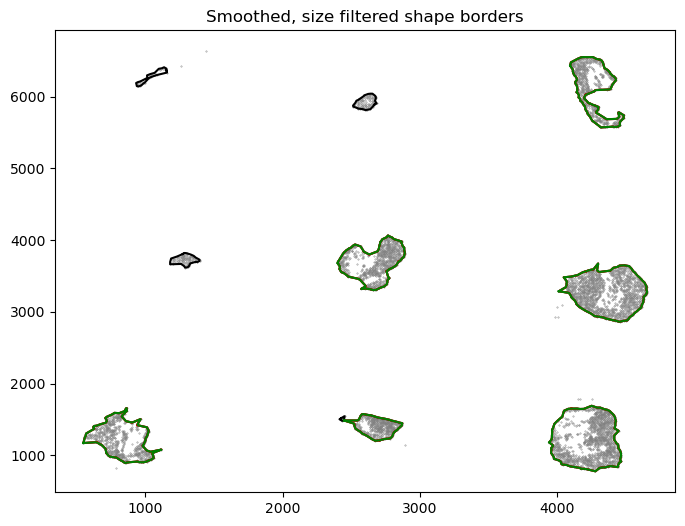

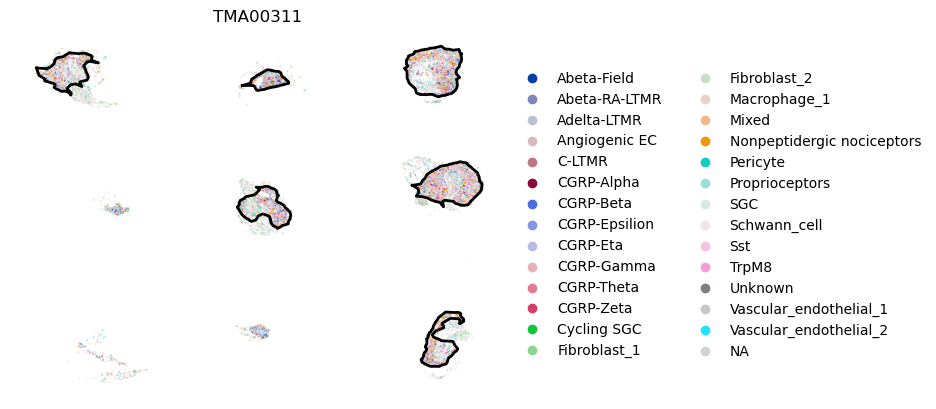

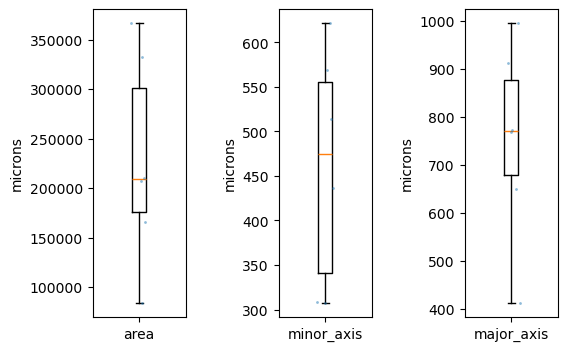

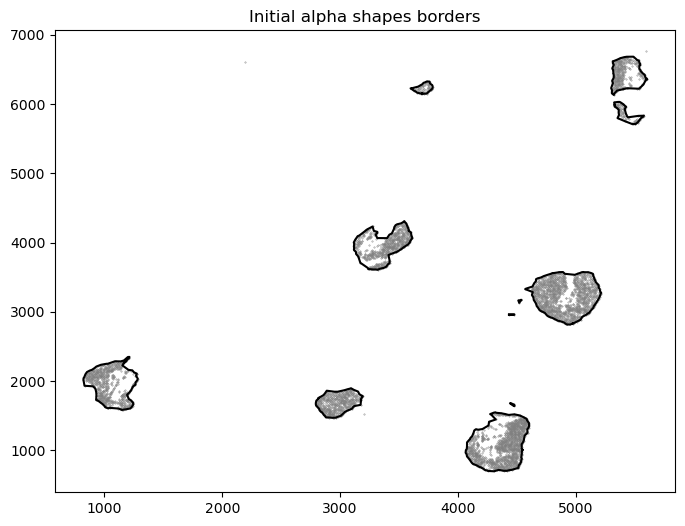

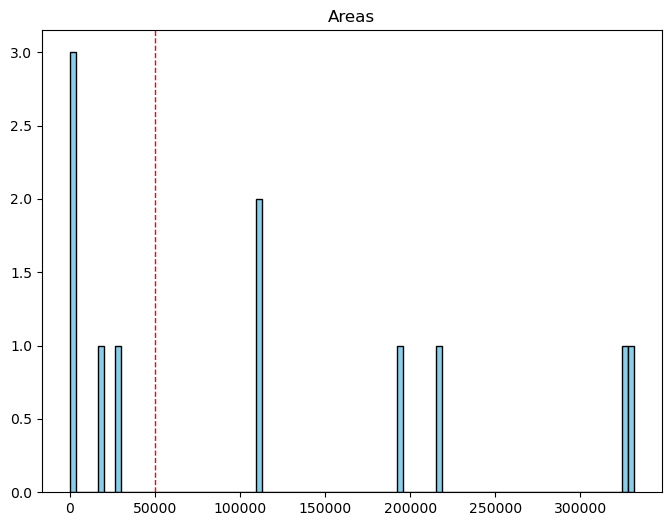

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


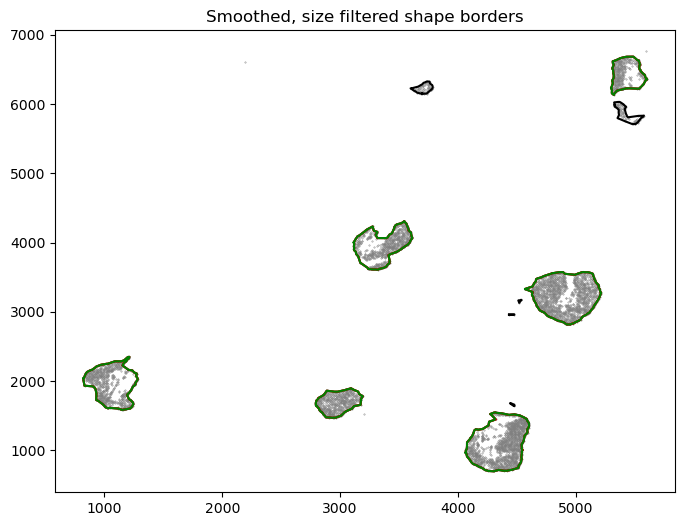

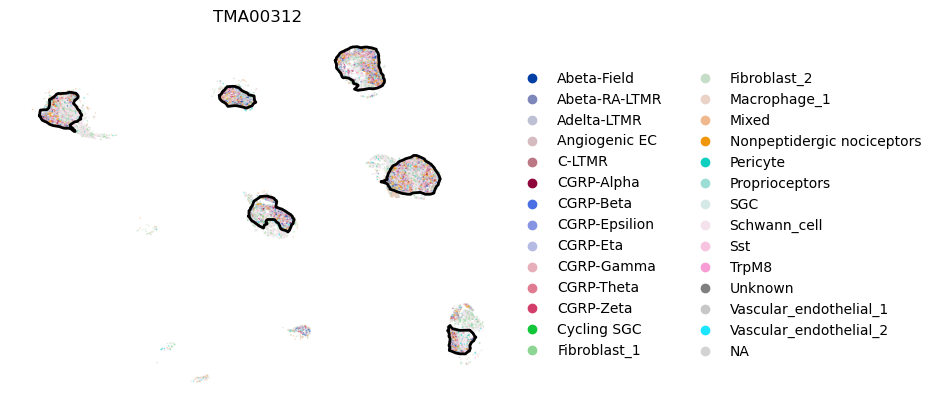

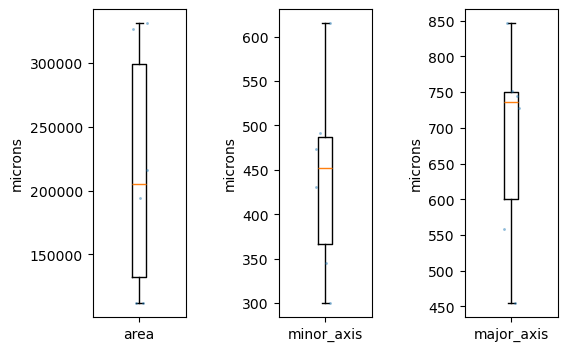

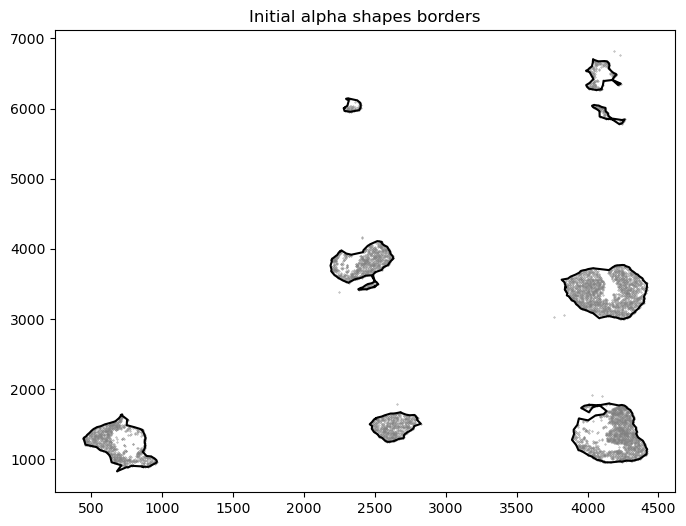

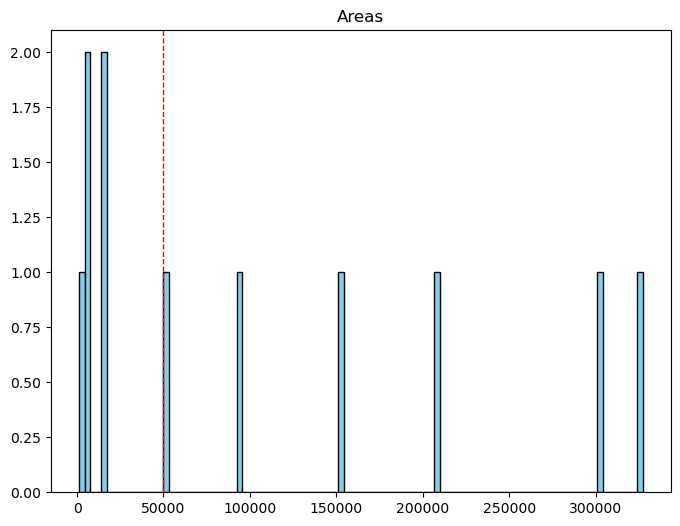

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


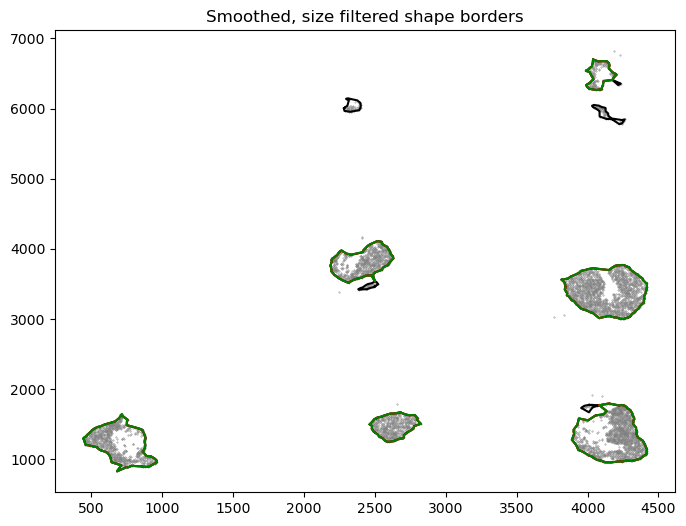

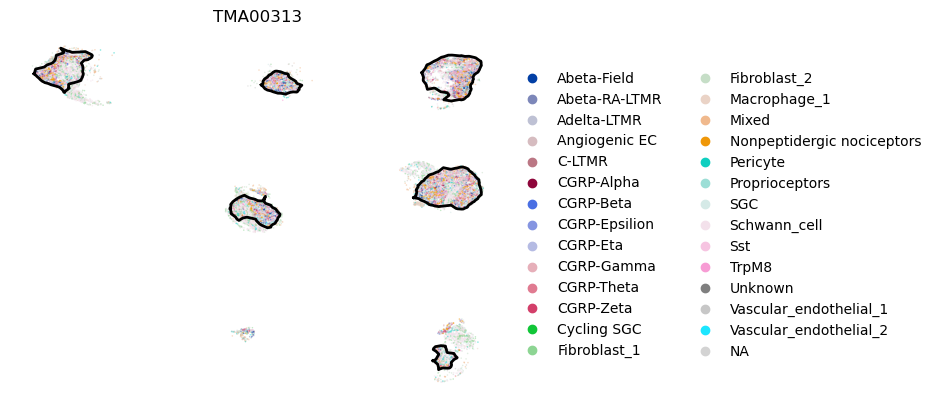

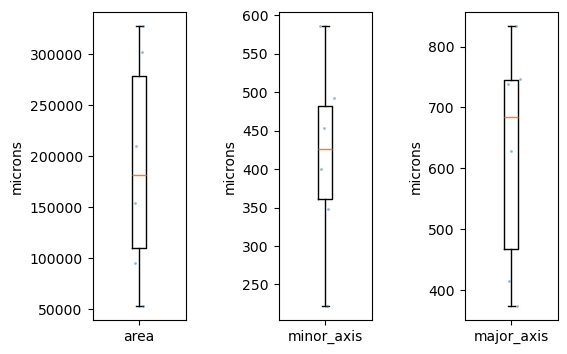

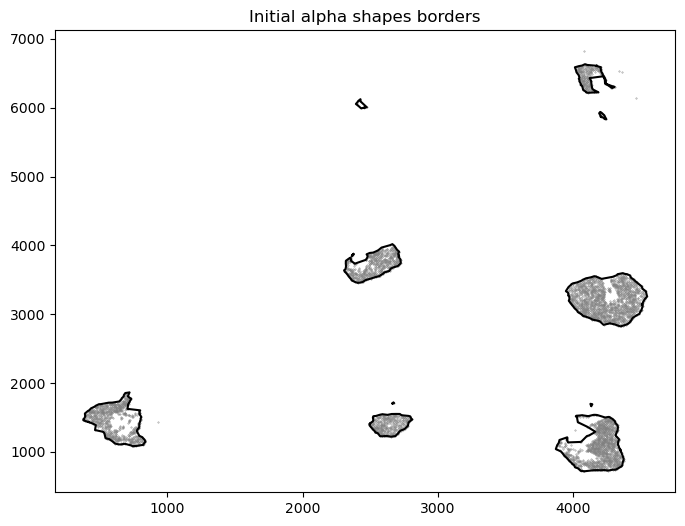

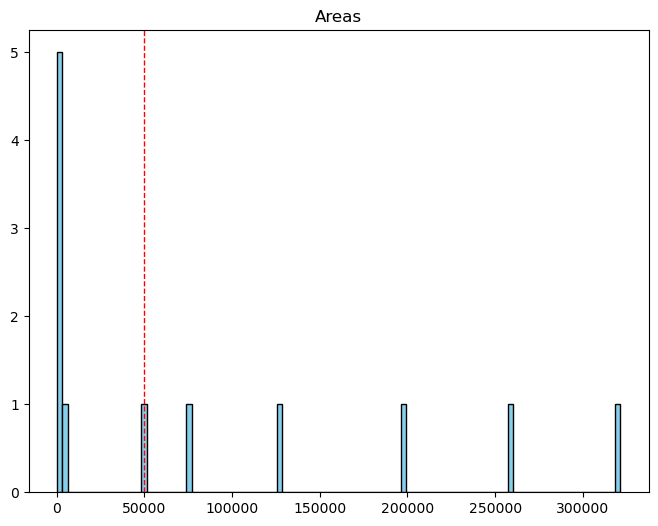

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


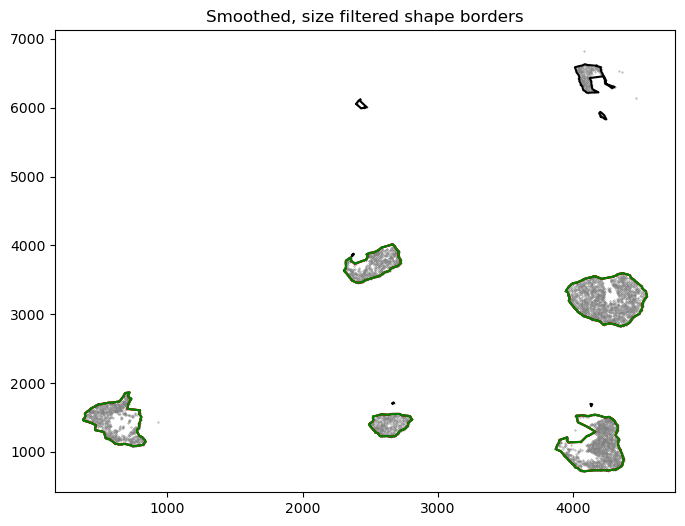

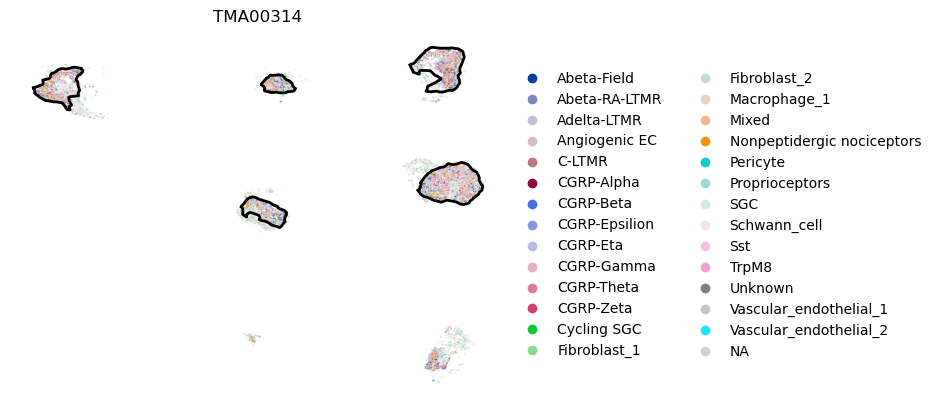

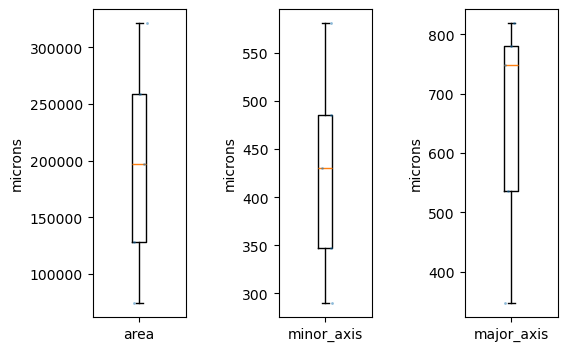

In [183]:
distance_out_dir = os.path.join(output_dir, 'distance')
if not os.path.exists (distance_out_dir):
    os.makedirs(distance_out_dir)
    
# set these to include all cells in the dataset 
zone_column = 'seurat_labels'

# either use all cells
# zone_id = adata_global.obs['seurat_labels'].unique().tolist()
# or only neurons
zone_id = adata.obs['seurat_labels'].unique().tolist()

# area_threshold = 3000
area_threshold = 50000
alpha=.02

adata_global.obs['drg_index'] = None
for sample in adata.obs['sample_id'].cat.categories:
# for sample in ['TMA00312']:
    
    adata_sample = adata_global[adata_global.obs['sample_id']==sample, :].copy()

    # get alphashapes
    alpha_shape = get_alphashape(adata_sample, zone_column, zone_id, alpha)

    if alpha_shape.geoms: # if there are no detected shapes, abort
    # if alpha_shape is None or alpha_shape.is_empty:
        # print(f"Skipping {sample}: No alpha shape detected.")
        # continue
        
        # process alphashapes
        poly, gdf = process_alphashape(alpha_shape, adata_sample, zone_column, zone_id,area_threshold = area_threshold, circularity_threshold = None)
        
        # plot shape borders in space with zones
        plot_spatial_zoom_polys(
            adata_sample,
            color=zone_column,
            palette=None,
            polygons=poly,
            # size = 50, 
            # x_lims=[4300, 5300], 
            # y_lims=[2800, 3800],
            invert_y=True,
            title=f"{sample}"
        )
        
        # plot shape metrics
        plot_shape_metrics(gdf, ['area', 'minor_axis', 'major_axis'])
    
        # save poly and gdf for each sample
        joblib.dump(poly, os.path.join(distance_out_dir, 'drg_poly_' + sample + '.pkl'))
        gdf.to_file(os.path.join(distance_out_dir, 'drg_gdf_' + sample + '.geojson'), driver="GeoJSON")  

        # add structure info (e.g. index) to adata
        structure_df = add_structure_info_to_adata(adata_sample, gdf, 'drg', sample, distance_out_dir)

        # update main adata object only for matching indices
        adata_global.obs.loc[structure_df.index, 'drg_index'] = structure_df['index'].astype(str) # .astype(object)
        adata_global.obs.loc[structure_df.index, ['drg_area', 'drg_centroid_x', 'drg_centroid_y']] = structure_df[['area', 'centroid_x', 'centroid_y']].values
  
    else:
        print(f"Skipping {sample}: No alpha shape detected.")

# make the drg index column sample specific and convert to category 
adata_global.obs['drg_index'] = adata_global.obs['sample_id'].astype(str) +'_'+ adata_global.obs['drg_index'].astype(str)
adata_global.obs['drg_index'] = adata_global.obs['drg_index'].astype('category')

In [184]:
import pandas as pd
from shapely.geometry import Point

def calculate_cell_distances_to_edge(adata, poly_obj):
    """
    Calculates the distance of each cell to the edge of the polygon it resides in.
    Cells outside all polygons will be assigned a distance of NaN.
    """
    # 1. Setup coordinate array and result column
    spatial_key = 'spatial' if 'spatial' in adata.obsm else 'X_spatial'
    coords = adata.obsm[spatial_key]
    distances = np.full(adata.n_obs, np.nan)
    
    # 2. Extract individual polygons
    # Handles both MultiPolygon and single Polygon objects
    geoms = poly_obj.geoms if hasattr(poly_obj, 'geoms') else [poly_obj]
    
    # 3. Iterate through polygons and find contained cells
    for poly in geoms:
        # Create a boundary object once (more efficient for distance checks)
        boundary = poly.boundary
        
        # Optimization: Only check cells within the polygon's bounding box
        minx, miny, maxx, maxy = poly.bounds
        mask = (coords[:, 0] >= minx) & (coords[:, 0] <= maxx) & \
               (coords[:, 1] >= miny) & (coords[:, 1] <= maxy)
        
        # For candidate cells, check if they are actually inside
        for i in np.where(mask)[0]:
            p = Point(coords[i])
            if poly.contains(p):
                # Calculate distance to the exterior boundary
                distances[i] = p.distance(boundary)
                
    # 4. Save results to adata
    adata.obs['dist_to_drg_edge'] = distances
    return adata

In [185]:
# Calculate disatnce to edge and add to 
for sample in adata.obs['sample_id'].cat.categories:
    poly_path = os.path.join(distance_out_dir, 'drg_poly_' + sample + '.pkl')
        
    # 1. Check if the file exists
    if not os.path.exists(poly_path):
        print(f'Skipping sample {sample}: Polygon file not found.')
        continue

    print('Calculating distance to edge for sample:', sample)
    
    # adata_sample = adata[adata.obs['sample_id']==sample, :].copy()
    adata_sample = adata_global[adata_global.obs['sample_id']==sample, :].copy()

    poly = joblib.load(os.path.join(distance_out_dir, 'drg_poly_' + sample + '.pkl'))
    
    # Calculate distances for the cells in this specific sample
    adata_sample = calculate_cell_distances_to_edge(adata_sample, poly)

    adata_global.obs.loc[adata_global.obs['sample_id'] == sample, 'dist_to_drg_edge'] = adata_sample.obs['dist_to_drg_edge']
    


Calculating distance to edge for sample: TMA00303
Calculating distance to edge for sample: TMA00304
Calculating distance to edge for sample: TMA00305
Calculating distance to edge for sample: TMA00306
Calculating distance to edge for sample: TMA00307
Calculating distance to edge for sample: TMA00308
Calculating distance to edge for sample: TMA00309
Calculating distance to edge for sample: TMA00310
Calculating distance to edge for sample: TMA00311
Calculating distance to edge for sample: TMA00312
Calculating distance to edge for sample: TMA00313
Calculating distance to edge for sample: TMA00314


/tmp/ipykernel_102/890191868.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_neurons_dist.obs.groupby('neuron_label')['dist_to_drg_edge']
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


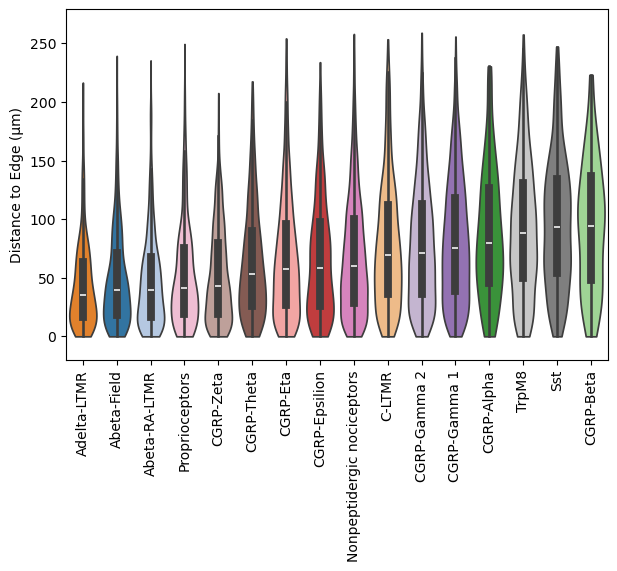

In [191]:
# violin plot- plottting all cells 

# plot distance, for neurons only
adata_neurons_dist = adata_global[~adata_global.obs['neuron_label'].isna(), :].copy()

# Filter to only include cells that actually fell inside a DRG polygon
# This removes the NaN values for cells outside alpha shapes
adata_neurons_dist = adata_neurons_dist[~adata_neurons_dist.obs['dist_to_drg_edge'].isna()].copy()

# Reorder the categories in the AnnData object
sorted_labels = (
    adata_neurons_dist.obs.groupby('neuron_label')['dist_to_drg_edge']
    .median()
    .sort_values()
    .index
)

# identify min and max distance values to set axis lims
min_dist = np.min(adata_neurons_dist.obs['dist_to_drg_edge'])
max_dist = np.max(adata_neurons_dist.obs['dist_to_drg_edge'])
sc.pl.violin(
    adata_neurons_dist, 
    keys='dist_to_drg_edge', 
    groupby='neuron_label', 
    rotation=90,
    order = sorted_labels,
    palette=neuron_label_palette_mapped, # Using your existing palette
    ylabel='Distance to Edge (µm)',
    stripplot=False, # Set to True if you want to see individual cell points
    inner = 'box', #  'quartile'
    show = False
)
plt.ylim(min_dist-20, max_dist+20)
plt.savefig(os.path.join(plot_out_dir, "drg_edge_distance_neurons_violin.pdf"), format='pdf', bbox_inches='tight')
plt.show()

/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/workspace/environment/space2/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values

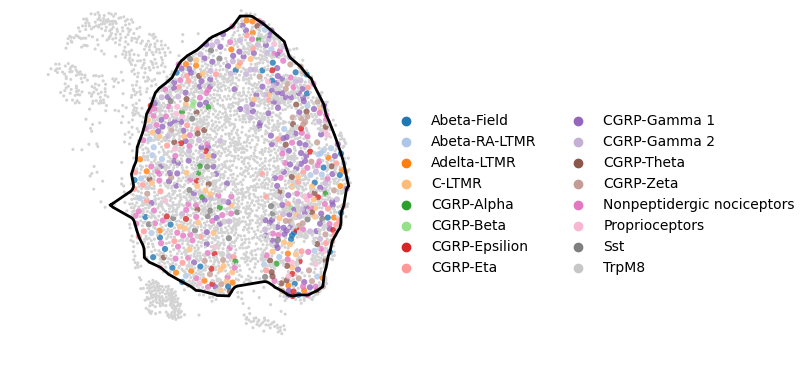

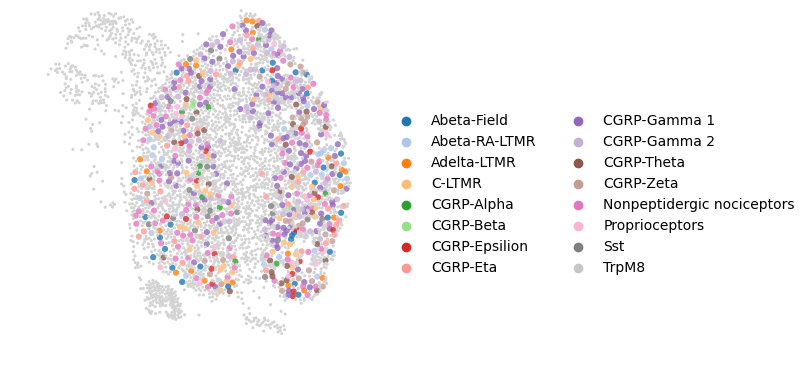

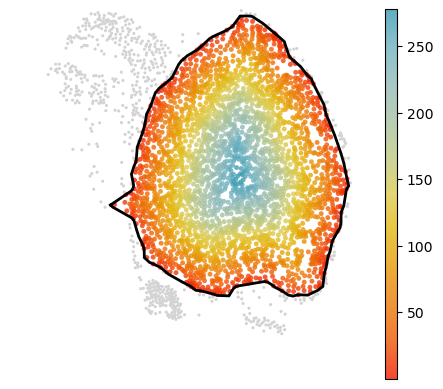

In [223]:
sample = 'TMA00312'

adata_sample = adata_global[adata_global.obs['sample_id']==sample, :].copy()
poly = joblib.load(os.path.join(distance_out_dir, 'drg_poly_' + sample + '.pkl'))
plot_spatial_zoom_polys(
    adata_sample,
    # color_col='seurat_labels',
    color_col='neuron_label',
    palette=neuron_label_palette_mapped,
    polygons=poly,
    size = 80, 
    size_bg = 20, 
    alpha=0.8,
    x_lims=[4300, 5300], 
    y_lims=[2800, 3800],
    invert_y=True,
)
plt.savefig(os.path.join(plot_out_dir, f"drg_spatial_example_neuron_labels_poly_{sample}.pdf"), format='pdf', bbox_inches='tight')

plot_spatial_zoom_polys(
    adata_sample,
    # color_col='seurat_labels',
    color_col='neuron_label',
    palette=neuron_label_palette_mapped,
    # polygons=poly,
    size = 80, 
    size_bg = 20, 
    alpha=0.8,
    x_lims=[4300, 5300], 
    y_lims=[2800, 3800],
    invert_y=True,
)
plt.savefig(os.path.join(plot_out_dir, f"drg_spatial_example_neuron_labels_{sample}.pdf"), format='pdf', bbox_inches='tight')

plot_spatial_zoom_polys(
    adata_sample,
    # color_col='seurat_labels',
    color_col='dist_to_drg_edge',
    palette=None,
    cmap = colormap_r,
    polygons=poly,
    size = 50, 
    alpha=0.8,
    x_lims=[4300, 5300], 
    y_lims=[2800, 3800],
    invert_y=True,
)
plt.savefig(os.path.join(plot_out_dir, f"drg_spatial_example_distance_poly_{sample}.pdf"), format='pdf', bbox_inches='tight')

In [187]:
mins = (
    adata_neurons_dist.obs.groupby('neuron_label')['dist_to_drg_edge']
    .min()
    .sort_values()
)
mins

/tmp/ipykernel_102/1803381807.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_neurons_dist.obs.groupby('neuron_label')['dist_to_drg_edge']


neuron_label
Nonpeptidergic nociceptors    0.000006
CGRP-Gamma 1                  0.000020
Abeta-RA-LTMR                 0.000031
CGRP-Eta                      0.000049
CGRP-Epsilion                 0.000063
C-LTMR                        0.000121
CGRP-Theta                    0.000169
CGRP-Zeta                     0.000412
Abeta-Field                   0.000565
Adelta-LTMR                   0.000909
Proprioceptors                0.001262
CGRP-Alpha                    0.002119
CGRP-Beta                     0.004146
TrpM8                         0.008827
CGRP-Gamma 2                  0.017741
Sst                           0.019449
Name: dist_to_drg_edge, dtype: float64

In [188]:
np.min(adata_neurons_dist.obs['dist_to_drg_edge'])

6.160144287719743e-06

number of unique DRG:  72
number of unique samples:  12


/tmp/ipykernel_102/1327189207.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist_summary = pd.DataFrame(adata_neurons_dist.obs.groupby([drg_grouping, 'neuron_label'])['dist_to_drg_edge'].median()
/tmp/ipykernel_102/1327189207.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_neurons_dist.obs.groupby('neuron_label')['dist_to_drg_edge']
/tmp/ipykernel_102/1327189207.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


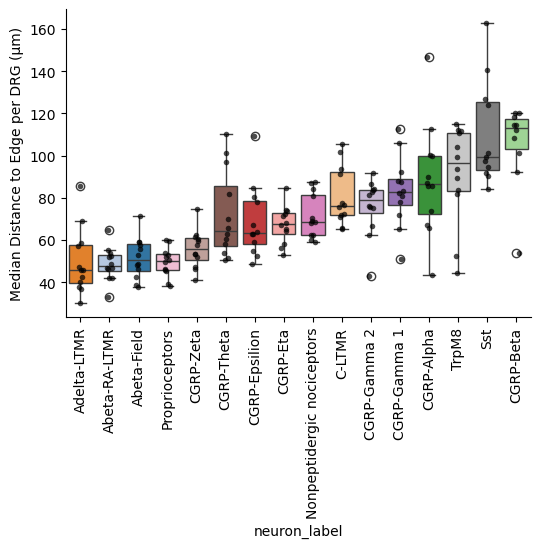

In [124]:
# plot at DRG level
# drg_grouping = 'drg_index'
drg_grouping = 'sample_id'


# plot distance, for neurons only
adata_neurons_dist = adata_global[~adata_global.obs['neuron_label'].isna(), :].copy()

print('number of unique DRG: ', len(adata_neurons_dist.obs['drg_index'].unique().tolist())) 
print('number of unique samples: ',  len(adata_neurons_dist.obs['sample_id'].unique().tolist())) 

# Filter to only include cells that actually fell inside a DRG polygon
# This removes the NaN values for cells outside alpha shapes
adata_neurons_dist = adata_neurons_dist[~adata_neurons_dist.obs['dist_to_drg_edge'].isna()].copy()

# Reorder the categories in the AnnData object
dist_summary = pd.DataFrame(adata_neurons_dist.obs.groupby([drg_grouping, 'neuron_label'])['dist_to_drg_edge'].median()
                            .sort_values()).reset_index()


# sort medians from the single cell data 
sorted_labels = (
    adata_neurons_dist.obs.groupby('neuron_label')['dist_to_drg_edge']
    .median()
    .sort_values()
    .index
)

# Create the plot
plt.figure(figsize=(6, 4))

# The Boxplot shows the distribution of medians across different DRGs
sns.boxplot(
    data=dist_summary, 
    x='neuron_label', 
    y='dist_to_drg_edge', 
    order=sorted_labels, 
    palette=neuron_label_palette_mapped,
    # showfliers=False,  
    # boxprops={'alpha': 0.3} # Makes boxes transparent
)

# The Stripplot adds the individual DRG points on top
sns.stripplot(
    data=dist_summary, 
    x='neuron_label', 
    y='dist_to_drg_edge', 
    order=order, 
    color='black', 
    size=4, 
    alpha=0.7,
    jitter=True 
)

plt.xticks(rotation=90)
plt.ylabel('Median Distance to Edge per DRG (µm)')
sns.despine()
plt.show()

In [157]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

def plot_dist_summary_with_stats(adata, drg_grouping, comparisons=None, palette=None, figsize=(6, 4)):
    """
    Plots all neuron labels and overlays t-test significance bars for specific pairs.
    
    Args:
        df: The dist_summary dataframe (must have neuron_label and dist_to_drg_edge).
        sorted_order: list/index of labels for the x-axis order.
        comparisons: List of tuples, e.g., [('Proprioceptor', 'Nociceptor')].
        palette: Dictionary mapping labels to colors.
    """

    
    # plot distance, for neurons only
    adata_neurons_dist = adata[~adata.obs['neuron_label'].isna(), :].copy()
    
    print('number of unique DRG: ', len(adata_neurons_dist.obs['drg_index'].unique().tolist())) 
    print('number of unique samples: ',  len(adata_neurons_dist.obs['sample_id'].unique().tolist())) 
    
    # Filter to only include cells that actually fell inside a DRG polygon
    # This removes the NaN values for cells outside alpha shapes
    adata_neurons_dist = adata_neurons_dist[~adata_neurons_dist.obs['dist_to_drg_edge'].isna()].copy()
    
    # Reorder the categories in the AnnData object
    df = pd.DataFrame(adata_neurons_dist.obs.groupby([drg_grouping, 'neuron_label'])['dist_to_drg_edge'].median()
                                .sort_values()).reset_index()
    
    
    # sort medians from the single cell data 
    sorted_order = (
        adata_neurons_dist.obs.groupby('neuron_label')['dist_to_drg_edge']
        .median()
        .sort_values()
        .index
    )
    
    plt.figure(figsize=figsize)
    
    # 1. Base Plot
    sns.boxplot(data=df, x='neuron_label', y='dist_to_drg_edge', 
                order=sorted_order, palette=palette, showfliers=False,
                # boxprops={'alpha': 0.4}
               )
    
    sns.stripplot(data=df, x='neuron_label', y='dist_to_drg_edge', 
                  order=sorted_order, color='black', alpha=0.6, jitter=0.2, size=4)
    
    # 2. Add Statistical Annotations
    if comparisons:
        # Get current y-limits to position bars
        y_max = df['dist_to_drg_edge'].max()
        # Increment height for each comparison to avoid stacking overlap
        bar_step = y_max * 0.12 
        
        for i, (g1, g2) in enumerate(comparisons):
            # Calculate T-test
            data1 = df[df['neuron_label'] == g1]['dist_to_drg_edge']
            data2 = df[df['neuron_label'] == g2]['dist_to_drg_edge']
            _, p_val = stats.ttest_ind(data1, data2, nan_policy='omit')
            
            # Find x-coordinates for the labels based on sorted_order
            x1 = list(sorted_order).index(g1)
            x2 = list(sorted_order).index(g2)
            
            # Set bar height
            h = y_max + (i + 1) * bar_step
            
            # Draw the bar (bracket)
            plt.plot([x1, x1, x2, x2], [h, h + (bar_step*0.2), h + (bar_step*0.2), h], 
                     lw=0.5, c='black')
            
            # Add p-value text
            # Formatting p-value for readability
            p_text = f"p={p_val:.4f}" if p_val > 0.0001 else "p<0.0001"
            plt.text((x1 + x2) / 2, h + (bar_step*0.2), p_text, 
                     ha='center', va='bottom', fontsize=10, )

    plt.xticks(rotation=90)
    plt.xlabel('')
    plt.ylabel('Median Distance to Edge (µm)')
    sns.despine()
    
    # Adjust y-limit to fit the bars
    if comparisons:
        plt.ylim(None, y_max + (len(comparisons) + 1) * bar_step)
        
    plt.tight_layout()
    plt.show()

number of unique DRG:  72
number of unique samples:  12


/tmp/ipykernel_102/1924763174.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.DataFrame(adata_neurons_dist.obs.groupby([drg_grouping, 'neuron_label'])['dist_to_drg_edge'].median()
/tmp/ipykernel_102/1924763174.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_neurons_dist.obs.groupby('neuron_label')['dist_to_drg_edge']
/tmp/ipykernel_102/1924763174.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='neuron_label', y='dist_to_d

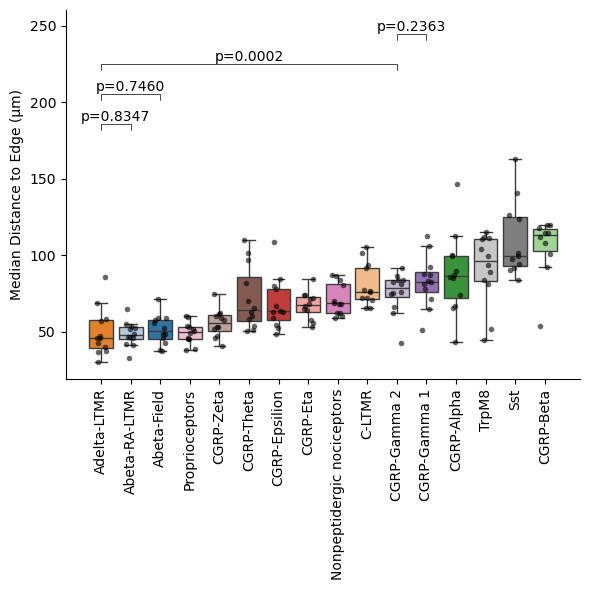

number of unique DRG:  72
number of unique samples:  12


/tmp/ipykernel_102/1924763174.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.DataFrame(adata_neurons_dist.obs.groupby([drg_grouping, 'neuron_label'])['dist_to_drg_edge'].median()
/tmp/ipykernel_102/1924763174.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_neurons_dist.obs.groupby('neuron_label')['dist_to_drg_edge']
/tmp/ipykernel_102/1924763174.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='neuron_label', y='dist_to_d

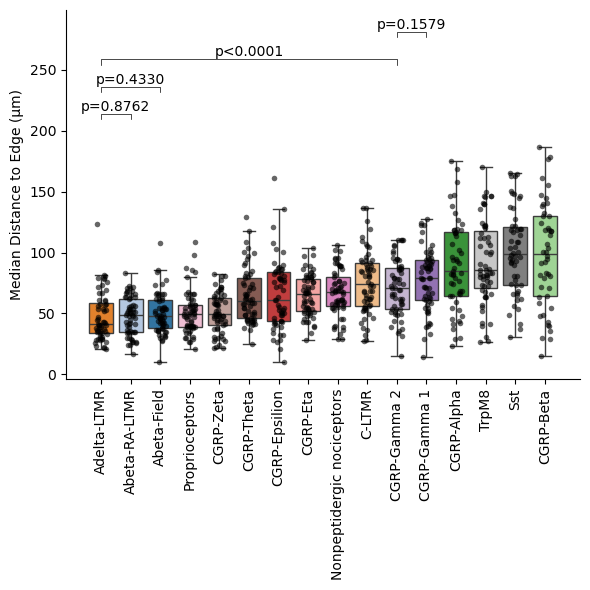

In [159]:
pairwise_comparisons = [
    (['Adelta-LTMR', 'Abeta-RA-LTMR']),
    (['Adelta-LTMR', 'Abeta-Field']), 
    (['Adelta-LTMR', 'CGRP-Gamma 2']),
    (['CGRP-Gamma 1', 'CGRP-Gamma 2'])
]
plot_dist_summary_with_stats(adata_global, 
                             drg_grouping = 'sample_id',
                             comparisons = pairwise_comparisons, palette = neuron_label_palette_mapped,
                             figsize=(6, 6))

plot_dist_summary_with_stats(adata_global, 
                             drg_grouping = 'drg_index',
                             comparisons = pairwise_comparisons, palette = neuron_label_palette_mapped,
                             figsize=(6, 6))


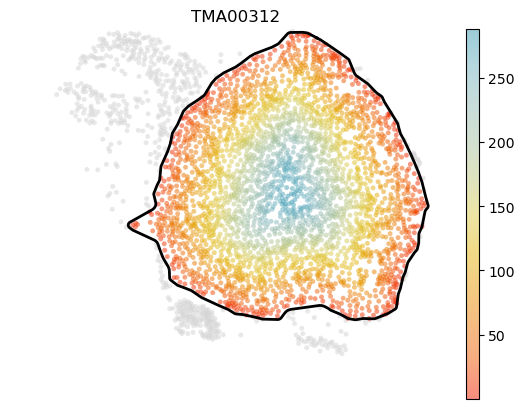

<Axes: title={'center': 'TMA00312'}, xlabel='spatial1', ylabel='spatial2'>

In [87]:
sample = 'TMA00312'
adata_sample = adata_global[adata_global.obs['sample_id']==sample, :].copy()
poly = joblib.load(os.path.join(distance_out_dir, 'drg_poly_' + sample + '.pkl'))
plot_spatial_zoom_polys(
    adata_sample,
    color='dist_to_drg_edge',
    palette=None,
    cmap = colormap_r,
    polygons=poly,
    size = 50, 
    x_lims=[4300, 5300], 
    y_lims=[2800, 3800],
    invert_y=True,
    title=f"{sample}"
)